# Bölüm 2 — İlaç Sektörü Satış ve Talep Analizi (tek dosya sürümü)

Dört pazar (A, B, C, D) × 124 ay (2016-01 → 2026-04) satış verisi üzerinde case'in
yedi analiz sorusu.

> 📦 **Bu notebook kendi kendine yeterlidir.** `src/analysis/` altındaki beş modülün
> (`load`, `clean`, `metrics`, `forecast`, `plots`) tamamı aşağıya fonksiyon olarak
> yazıldı; hiçbir proje modülü import edilmiyor. Tek gereken veri dosyası
> `bolum2_veriseti.xlsx`.

Her görevin altında iki ayrı yorum var: **Teknik yorum** (yöntem, sınırlılık,
istatistiksel güven) ve **İş yorumu** (ne yapılmalı).

> ⚠️ **Önce okunması gereken:** `MF Oran` kolonu B Pazarı'nda yüzde (0–100),
> diğer pazarlarda oran (0–1) ölçeğinde. Düzeltilmezse `Net Kutu = Brüt × (1 − MF)`
> negatife düşüyor ve birim fiyat 8,32 TL yerine **−0,88 TL** çıkıyor. A4, A6 ve A7
> bu düzeltme olmadan tamamen yanlış olurdu. Düzeltme sabit "B Pazarı" kuralıyla
> değil, **grup medyanına bakan program tespitiyle** yapılıyor.

---
## Yönetici özeti

Aşağıdaki her satır bu notebook'ta hesaplanmış bir sayıya dayanır; ilgili bölümde
kodu ve grafiği var.

| # | Soru | Bulgu |
|---|---|---|
| **A1** | Son 2 yılın performansı | Dört pazarda hacim sıralaması ciro sıralamasıyla **uyuşmuyor**: D Pazarı kutuda ikinci, ciroda sonuncuya yakın. C Pazarı'nda hacmin **%100'ü** tek üründe, B'de %69,5'i `Ürün-FR`'de — ciddi konsantrasyon riski |
| **A2** | Pazar payı ve rekabet | Şirket 1 dört pazarda da **%15'in altında** (A %12,4 · B %13,3 · C %6,1 · D %4,0). HHI dört pazarda da düşüyor → rekabet artıyor. Şirket 1 her pazarda pazardan hızlı büyümüş, ama C ve D'deki üç haneli CAGR **sıfıra yakın tabandan** geliyor |
| **A3** | Mevsimsellik | **Güçlü mevsimsellik yok**: 16 hesaplanabilir serinin 15'inde güç 0,50'nin altında. Tek sistematik örüntü A Pazarı'nda **Temmuz zirvesi** (10 üründen 7'si). İki seri için hesap yapılamadı, uydurulmadı |
| **A4** | MF'in satışa etkisi | 🚨 A Pazarı'nda **anlamlı ve ters yönlü**: yüksek MF ayını izleyen ayda medyan değişim **−%21,7**, normal aylarda +%1,0 (Mann-Whitney p ≈ 3×10⁻¹², FDR q ≈ 9×10⁻¹², Cliff δ = −0,49). Kanal doldurma örüntüsü. B ve D'de anlamlı değil, C'de hiç olay yok |
| **A5** | Rakip karşılaştırması | 🚨 "Diğer Şirket hacim kaybediyor" **mutlak hacimde doğrulanmıyor** — C'de +6.066 ve D'de +17.863 kutu/ay ile anlamlı biçimde **artıyor**. Kayıp yalnız **pay** düzeyinde (A'da −12,2 puan). Pay değişimleri toplamı her pazarda 0 → tutarlılık kontrolü geçti |
| **A6** | Fiyat ve promosyon maliyeti | Birim fiyat on yılda ~10 katına çıkmış (A: 8,2 → 86,8 TL). D Pazarı diğerlerinin **yarı fiyatında** (47,0 TL). Promosyonun on yıllık maliyeti **108,3 milyon TL** = cironun **%2,93'ü**, 2025'te tek başına 23,0 milyon TL |
| **A7** | Talep tahmini | 🚨 **Tek mimari her pazarda geçerli değil**: dört pazarda üç farklı kazanan (A: `snaive` WAPE 16,9 · B ve C: `ma3` 10,8 / 9,9 · D: `lgbm` 52,9). MF özellikleri **dört pazarın üçünde** iyileştiriyor, C'de kötüleştiriyor — A4'te C'de hiç MF olayı olmamasıyla tutarlı |

**En kritik teknik bulgu:** `MF Oran` B Pazarı'nda yüzde ölçeğinde. Düzeltilmeden
A4, A6 ve A7 tamamen yanlış olurdu (birim fiyat −0,88 TL çıkıyor). Düzeltme sabit
pazar adına değil, grup medyanına bakan **program tespitine** dayanıyor.

**Birlikte okununca:** A4 promosyonun talep yaratmayıp öne çektiğini, A6 bunun yılda
23 milyon TL'ye mal olduğunu gösteriyor. İkisi birlikte promosyon bütçesinin geri
dönüşünü sorgulamak için yeterli kanıt oluşturuyor.

---
## 0. Kurulum ve veri yolu

Aşağıdaki hücre gerekli kütüphaneleri kurar. Sürümler kurulu ortamdan (`pip freeze`)
birebir alındı, tahmin edilmedi.

In [1]:
# Gerekli kütüphaneler. Ortamda zaten varsa pip bunları atlar.
%pip install --quiet \
    "pandas==2.2.3" \
    "numpy==2.2.6" \
    "openpyxl==3.1.5" \
    "matplotlib==3.10.9" \
    "statsmodels==0.14.6" \
    "scipy==1.15.3" \
    "scikit-learn==1.7.2" \
    "lightgbm==4.7.0"

print("Kurulum tamam.")

Note: you may need to restart the kernel to use updated packages.
Kurulum tamam.


In [2]:
# Veri dosyasının yeri. Notebook ile aynı klasörde ya da bir üstünde aranır;
# bulunamazsa DATA_PATH'i elle yazın.
from pathlib import Path

_CANDIDATES = [
    Path("bolum2_veriseti.xlsx"),
    Path("veri") / "bolum2_veriseti.xlsx",
    Path("..") / "bolum2_veriseti.xlsx",
    Path("..") / "AI Engineer" / "bolum2_veriseti.xlsx",
    Path("AI Engineer") / "bolum2_veriseti.xlsx",
]
DATA_PATH = next((p for p in _CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "bolum2_veriseti.xlsx bulunamadı. Aranan yerler:\n  "
        + "\n  ".join(str(p.resolve()) for p in _CANDIDATES)
        + "\n\nDosyayı bu notebook'un yanına koyun ya da DATA_PATH'i elle atayın."
    )

# Figürler buraya yazılır.
FIGURE_DIR = Path("figures")
print(f"Veri : {DATA_PATH.resolve()}")
print(f"Figür: {FIGURE_DIR.resolve()}")

Veri : bolum2_veriseti.xlsx
Figür: figures


---
## 0.1 Analiz fonksiyonları

`src/analysis/` altındaki beş modülün tamamı burada. Sırasıyla: yükleme (`load`),
temizleme (`clean`), türetilmiş metrikler (`metrics`), tahmin (`forecast`) ve
grafik stili (`plots`).

In [3]:
import warnings
from collections.abc import Callable
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

MARKETS = ["A Pazarı", "B Pazarı", "C Pazarı", "D Pazarı"]
KEY = ["pazar", "sirket", "urun"]

In [4]:
# ============================================================================
# src/analysis/load.py — geniş formatlı çalışma kitabını tidy çerçeveye çevirir
# ============================================================================
# Kaynak sayfa 3 satırlık hiyerarşik başlık taşır (Yıl / Ay / Metrik) ve anahtarlar
# ilk üç kolondadır; `pd.read_excel(header=0)` bu yapıyı yanlış okur. Bu bölüm ham
# veriyi sadakatle okur — düzeltmelerin tamamı temizleme adımının işidir.
#
# DataFrame kolon adları bilinçli olarak Türkçe: kaynak Excel başlıkları
# (`Brüt Kutu`, `MF Oran`, `Net TL`) Türkçe ve bu ad eşlemesi veriye
# izlenebilirliği koruyor.

MONTH_NAMES = {
    "Ocak": 1,
    "Şubat": 2,
    "Mart": 3,
    "Nisan": 4,
    "Mayıs": 5,
    "Haziran": 6,
    "Temmuz": 7,
    "Ağustos": 8,
    "Eylül": 9,
    "Ekim": 10,
    "Kasım": 11,
    "Aralık": 12,
}

EXPECTED_METRICS = {"Brüt Kutu", "MF Oran", "Net TL"}
_METRIC_COLUMNS = {"Brüt Kutu": "brut_kutu", "MF Oran": "mf_oran", "Net TL": "net_tl"}

_YEAR_ROW = 1
_MONTH_ROW = 2
_METRIC_ROW = 3
_FIRST_DATA_ROW = 4
_FIRST_VALUE_COL = 3


def load_raw(path=None) -> pd.DataFrame:
    """Çalışma kitabını okur ve tidy çerçeve döndürür.

    Kolonlar: pazar, sirket, urun, tarih, brut_kutu, mf_oran, net_tl.
    Boş hücreler `NaN` kalır — sıfıra çevrilmez, çünkü ürünün henüz var olmadığı
    dönem ile gerçek sıfır satış farklı şeylerdir (bulgular §2.4).
    """
    raw = pd.read_excel(DATA_PATH if path is None else path, sheet_name=0, header=None)

    years = raw.iloc[_YEAR_ROW, _FIRST_VALUE_COL:].ffill().astype(int)
    months = raw.iloc[_MONTH_ROW, _FIRST_VALUE_COL:].ffill().astype(str).str.strip()
    metrics = raw.iloc[_METRIC_ROW, _FIRST_VALUE_COL:].astype(str).str.strip()

    unknown_months = set(months) - set(MONTH_NAMES)
    if unknown_months:
        raise ValueError(f"bilinmeyen ay adı: {sorted(unknown_months)}")
    if set(metrics) != EXPECTED_METRICS:
        raise ValueError(f"beklenmeyen metrik adları: {sorted(set(metrics))}")

    dates = [
        pd.Timestamp(year=year, month=MONTH_NAMES[month], day=1)
        for year, month in zip(years, months, strict=True)
    ]

    body = raw.iloc[_FIRST_DATA_ROW:, :]
    keys = body.iloc[:, :_FIRST_VALUE_COL].copy()
    keys.columns = KEY

    values = body.iloc[:, _FIRST_VALUE_COL:].apply(pd.to_numeric, errors="coerce")
    values.columns = pd.MultiIndex.from_arrays([dates, metrics.tolist()], names=["tarih", "metrik"])
    values.index = pd.MultiIndex.from_frame(keys)

    tidy = values.stack("tarih", future_stack=True).reset_index()
    tidy = tidy.rename(columns=_METRIC_COLUMNS).rename_axis(columns=None)
    tidy["pazar"] = tidy["pazar"].astype("category")
    tidy["sirket"] = tidy["sirket"].astype("category")
    tidy["urun"] = tidy["urun"].astype(str)

    ordered = [*KEY, "tarih", "brut_kutu", "mf_oran", "net_tl"]
    return tidy[ordered].sort_values([*KEY, "tarih"]).reset_index(drop=True)

In [5]:
# ============================================================================
# src/analysis/clean.py — ölçülmüş yedi veri kalitesi sorununu düzeltir
# ============================================================================
# Her adım hem veriyi değiştirir hem de ne yaptığını sayar; `DataQualityReport`
# notebook'un açılışında yayımlanır. Hiçbir kayıt sessizce silinmez.
#
# 🚨 En kritik adım MF ölçek düzeltmesidir (`detect_mf_scale`). `MF Oran` kolonu
# B Pazarı'nda yüzde (0–100), diğerlerinde oran (0–1) ölçeğindedir. Düzeltme
# yapılmazsa `Net Kutu = Brüt × (1 − MF)` negatife düşer, birim fiyat 8,32 TL
# yerine −0,88 TL çıkar ve A4, A6, A7 görevlerinin tamamı yanlış olur.

MF_LOWER = 0.0
MF_UPPER = 0.95
SHORT_SERIES_THRESHOLD = 24


@dataclass
class DataQualityReport:
    """Temizlemenin ne yaptığının sayısal dökümü."""

    raw_rows: int = 0
    clean_rows: int = 0
    rescaled_markets: dict = field(default_factory=dict)
    mf_clipped: int = 0
    return_rows: int = 0
    pre_launch_dropped: int = 0
    short_series: dict = field(default_factory=dict)


def detect_mf_scale(df: pd.DataFrame) -> dict:
    """Her pazar için MF biriminin ölçek faktörünü döndürür (1.0 veya 100.0).

    Kural veriden çıkar, pazar adından değil: pozitif MF değerlerinin medyanı 1'i
    aşıyorsa o pazar yüzde ölçeğindedir. Sıfırlar medyana katılmaz — MF'in çoğu ayda
    0 olduğu bir seride sıfırlar medyanı 0'a çeker ve ölçek sorunu gözden kaçardı.
    """
    factors = {}
    for market, group in df.groupby("pazar", observed=True):
        positive = group.loc[group["mf_oran"].notna() & (group["mf_oran"] > 0), "mf_oran"]
        median = positive.median()
        factors[str(market)] = 100.0 if pd.notna(median) and median > 1 else 1.0
    return factors


def clean(df: pd.DataFrame):
    """Yedi düzeltmeyi sırayla uygular ve kalite raporuyla birlikte döndürür."""
    report = DataQualityReport(raw_rows=len(df))
    result = df.copy()

    # V7 — ürün adı normalizasyonu. Ölçek tespitinden önce gelir ki gruplama doğru olsun.
    result["urun"] = result["urun"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

    # V2 — 🚨 MF ölçek düzeltmesi.
    factors = detect_mf_scale(result)
    report.rescaled_markets = {m: f for m, f in factors.items() if f != 1.0}
    divisor = result["pazar"].astype(str).map(factors)
    result["mf_oran_olcekli"] = result["mf_oran"] / divisor

    # V3 — ölçek düzeltmesinden sonra bile kalan imkânsız değerleri kırp ve bayrakla.
    result["mf_kirpildi"] = result["mf_oran_olcekli"].notna() & (
        (result["mf_oran_olcekli"] < MF_LOWER) | (result["mf_oran_olcekli"] > MF_UPPER)
    )
    result["mf_oran_temiz"] = result["mf_oran_olcekli"].clip(MF_LOWER, MF_UPPER)
    report.mf_clipped = int(result["mf_kirpildi"].sum())

    # V4 — iadeler. Silinmez; toplamlarda kalır, tahmin girdisinde 0'lanır.
    result["iade_mi"] = (result["brut_kutu"] < 0) | (result["net_tl"] < 0)
    report.return_rows = int(result["iade_mi"].sum())

    # V5 — serinin ilk pozitif satışından önceki dönem ürünün var olmadığı dönemdir.
    before = len(result)
    first_sale = result[result["brut_kutu"] > 0].groupby(KEY, observed=True)["tarih"].min()
    key_index = pd.MultiIndex.from_frame(result[KEY].astype(str))
    launch = pd.Series(
        key_index.map(first_sale.rename_axis(first_sale.index.names)), index=result.index
    )
    result = result[launch.notna() & (result["tarih"] >= launch)]
    report.pre_launch_dropped = before - len(result)

    result = result.reset_index(drop=True)
    report.clean_rows = len(result)
    report.short_series = _short_series(result)
    return result, report


def _short_series(df: pd.DataFrame) -> dict:
    """Mevsimsellik ve tahmin için yetersiz uzunluktaki seriler (V9).

    Uzunluk ölçüsü **satış görülen ay sayısı**dır, satır sayısı değil. Fark önemli:
    `C Pazarı/Ürün 1` kırpma sonrası 27 satır taşır ama bunların yalnız biri pozitif
    (2024-01'de 1 kutu), gerisi gerçek sıfır. Satır sayısıyla ölçülseydi seri
    "27 aylık geçmişi var" görünür ve mevsimsellik/tahmin için uygun sanılırdı.

    Bu seriler analizden **çıkarılmaz**; raporda listelenir ki notebook onları
    gizlemek yerine açıkça "yetersiz veri" diye gösterebilsin.
    """
    if df.empty:
        return {}
    with_sales = df[df["brut_kutu"] > 0].groupby(KEY, observed=True).size()
    return {
        tuple(map(str, key)): int(n) for key, n in with_sales.items() if n < SHORT_SERIES_THRESHOLD
    }

In [6]:
# ============================================================================
# src/analysis/metrics.py — türetilmiş satış metrikleri ve analitik ölçüler
# ============================================================================
# Türetilmiş metrikler case'in tanımlarından gelir:
#
#     Net Kutu    = Brüt Kutu × (1 − MF Oran)
#     Birim Fiyat = Net TL / Net Kutu
#
# Birim fiyat hesabı `NaN` üretir, `inf` değil: Net Kutu sıfır veya negatifse fiyat
# tanımsızdır ve sonsuz bir değer bütün ortalamaları sessizce zehirlerdi (V8).

SEASONALITY_MIN_MONTHS = 24
_PERIOD = 12


def derived_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """`net_kutu` ve `birim_fiyat` kolonlarını ekler."""
    result = df.copy()
    result["net_kutu"] = result["brut_kutu"] * (1 - result["mf_oran_temiz"])
    result["birim_fiyat"] = np.where(
        result["net_kutu"] > 0,
        result["net_tl"] / result["net_kutu"].where(result["net_kutu"] > 0),
        np.nan,
    )
    return result


def market_share(df: pd.DataFrame, metric: str = "brut_kutu") -> pd.DataFrame:
    """Pazar-ay bazında şirket payı (%)."""
    totals = df.groupby(["pazar", "tarih", "sirket"], observed=True)[metric].sum().reset_index()
    market_total = totals.groupby(["pazar", "tarih"], observed=True)[metric].transform("sum")
    totals["pay"] = 100.0 * totals[metric] / market_total
    return totals


def hhi(df: pd.DataFrame, metric: str = "brut_kutu") -> pd.DataFrame:
    """Herfindahl-Hirschman endeksi (0–10.000) — pazar-ay bazında yoğunlaşma."""
    shares = market_share(df, metric)
    result = shares.groupby(["pazar", "tarih"], observed=True)["pay"].apply(
        lambda p: float((p**2).sum())
    )
    return result.rename("hhi").reset_index()


def yoy_growth(df: pd.DataFrame, metric: str = "brut_kutu") -> pd.DataFrame:
    """Pazar-şirket-yıl bazında yıllık büyüme (%)."""
    yearly = df.copy()
    yearly["yil"] = yearly["tarih"].dt.year
    totals = yearly.groupby(["pazar", "sirket", "yil"], observed=True)[metric].sum().reset_index()
    totals = totals.sort_values(["pazar", "sirket", "yil"])
    previous = totals.groupby(["pazar", "sirket"], observed=True)[metric].shift(1)
    totals["buyume"] = np.where(
        previous > 0, 100.0 * (totals[metric] - previous) / previous, np.nan
    )
    return totals


def seasonal_index(series: pd.Series):
    """Ay bazında mevsimsel çarpan (ortalama 1,0 civarı). Kısa seride `None`.

    STL kullanılır (`robust=True`): veride promosyon kaynaklı sıçramalar var ve
    klasik ayrıştırma onlara aşırı tepki verip mevsimselliği çarpıtıyor. 24 aydan
    kısa serilerde hesap **yapılmaz** — 12 aylık döngünün en az iki tekrarı gerekir,
    yoksa uydurulmuş bir mevsimsellik raporlanır (V9).
    """
    components = _stl_components(series)
    if components is None:
        return None
    seasonal = components.seasonal
    mean = series.mean()
    if not np.isfinite(mean) or mean == 0:
        return None
    index = (seasonal + mean) / mean
    return index.groupby(index.index.month).mean().rename_axis("ay")


def seasonality_strength(series: pd.Series):
    """Hyndman mevsimsellik gücü: `max(0, 1 − Var(kalan) / Var(kalan + mevsimsel))`."""
    components = _stl_components(series)
    if components is None:
        return None
    residual = components.resid
    total = residual + components.seasonal
    if total.var() == 0:
        return 0.0
    return float(max(0.0, 1.0 - residual.var() / total.var()))


def _stl_components(series: pd.Series):
    """STL ayrıştırması; bilgilendirici geçmiş yetersizse `None`.

    Eşik **satış görülen ay** sayısına bakar, satır sayısına değil. Fark ölçüldü:
    `C Pazarı/Ürün 1` kırpma sonrası 28 satır taşıyor ama yalnız bir ayında satış
    var; satır sayısına bakan bir eşik bunu kabul ediyor ve STL o tek sıçramayı
    mevsimsellik olarak raporluyordu (güç 0,987, zirve indeksi 8,72). Uydurulmuş
    mevsimsellik, "hesaplanamadı" demekten daha kötüdür.
    """
    from statsmodels.tsa.seasonal import STL

    clean_series = series.dropna()
    months_with_sales = int((clean_series > 0).sum())
    if len(clean_series) < SEASONALITY_MIN_MONTHS or months_with_sales < SEASONALITY_MIN_MONTHS:
        return None
    if clean_series.nunique() <= 1:
        return None
    return STL(clean_series, period=_PERIOD, robust=True).fit()


def promo_revenue_loss(df: pd.DataFrame) -> pd.DataFrame:
    """Bedava verilen kutuların TL karşılığı — yıl × pazar × ürün toplamı."""
    result = df.copy()
    result["bedava_kutu"] = result["brut_kutu"] * result["mf_oran_temiz"]
    result["gelir_kaybi_tl"] = result["bedava_kutu"] * result["birim_fiyat"]
    result["yil"] = result["tarih"].dt.year
    return (
        result.groupby(["yil", "pazar", "urun"], observed=True)["gelir_kaybi_tl"]
        .sum()
        .reset_index()
    )


def price_dispersion(df: pd.DataFrame) -> pd.DataFrame:
    """Aynı ürünün pazarlar arası fiyat varyasyon katsayısı (CV).

    Anahtar `urun` değil `(pazar, urun)`; `Ürün-A` birden fazla şirkette geçtiği için
    ortalama önce pazar-ürün bazında alınır (V6).
    """
    per_market = df.groupby(["urun", "pazar"], observed=True)["birim_fiyat"].mean().reset_index()
    summary = per_market.groupby("urun", observed=True)["birim_fiyat"].agg(["mean", "std", "count"])
    summary["cv"] = np.where(
        summary["mean"] > 0, summary["std"].fillna(0.0) / summary["mean"], np.nan
    )
    return summary.reset_index()

In [7]:
# ============================================================================
# src/analysis/forecast.py — temel modeller ve walk-forward değerlendirme
# ============================================================================
# Değerlendirme genişleyen pencereli walk-forward'dır: son 12 ay tek tek tahmin
# edilir ve her adımda model yalnız o ana kadarki geçmişi görür. Zaman serisinde tek
# bir train/test bölmesi yanıltıcıdır — tek bir aya denk gelen şans, modelin
# sıralamasını değiştirebilir.
#
# MAPE case'in istediği metrik ama sıfıra yakın gerçek değerlerde patlar; bu veride
# 9.536 sıfır aylık gözlem var. Bu yüzden MAPE yalnız `y > 0` gözlemlerde hesaplanır
# ve yanına sıfır-dayanıklı WAPE ile sMAPE konur (V10).

TEST_MONTHS = 12
MIN_TRAIN_MONTHS = 6

MF_FEATURES = ["mf_lag_0", "mf_lag_1", "mf_roll_mean_3"]
_BASE_FEATURES = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_12",
    "roll_mean_3",
    "roll_mean_6",
    "roll_std_3",
    "ay",
    "ceyrek",
    "yil_indeksi",
    "seri_uzunlugu",
]
_CATEGORICALS = ["pazar", "urun"]

Forecaster = Callable[[pd.Series], float]


def naive(history: pd.Series) -> float:
    """ŷ(t+1) = y(t)."""
    return float(history.iloc[-1])


def snaive(history: pd.Series) -> float:
    """ŷ(t+1) = y(t−11). Geçmiş 12 aydan kısaysa `naive`'e düşer."""
    if len(history) < 12:
        return naive(history)
    return float(history.iloc[-12])


def ma3(history: pd.Series) -> float:
    """ŷ(t+1) = son üç ayın ortalaması."""
    return float(history.iloc[-3:].mean())


def walk_forward(df: pd.DataFrame, forecaster, months: int = TEST_MONTHS) -> pd.DataFrame:
    """Her seri için son `months` ayı bir ay ileri tahmin eder.

    Eğitim penceresi genişler ve **hedef ayı hiçbir zaman içermez** — sızıntı testi
    bunu doğrular. `MIN_TRAIN_MONTHS`'tan kısa geçmişi olan seriler atlanır; tek
    gözlemli `C/Ürün 1` gibi seriler burada kodu kırardı.
    """
    rows = []
    for key, group in df.groupby(KEY, observed=True):
        series = group.sort_values("tarih").set_index("tarih")["brut_kutu"]
        series = series.fillna(0.0).clip(lower=0.0)  # V4: iadeler tahminde 0'lanır
        if len(series) < MIN_TRAIN_MONTHS + 1:
            continue
        targets = series.index[-min(months, len(series) - MIN_TRAIN_MONTHS) :]
        for target in targets:
            history = series.loc[series.index < target]
            if len(history) < MIN_TRAIN_MONTHS:
                continue
            rows.append(
                {
                    "pazar": key[0],
                    "sirket": key[1],
                    "urun": key[2],
                    "tarih": target,
                    "gercek": float(series.loc[target]),
                    "tahmin": float(forecaster(history)),
                }
            )
    return pd.DataFrame(rows, columns=["pazar", "sirket", "urun", "tarih", "gercek", "tahmin"])


def error_metrics(actual, predicted) -> dict:
    """MAE, RMSE, MAPE (%), WAPE (%), sMAPE (%).

    MAPE yalnız `actual > 0` gözlemlerde hesaplanır; hiç yoksa `NaN` döner —
    sonsuz bir değer tabloyu okunamaz hale getirirdi.
    """
    y = np.asarray(actual, dtype=float)
    yhat = np.asarray(predicted, dtype=float)
    error = np.abs(y - yhat)

    positive = y > 0
    mape = float(100.0 * np.mean(error[positive] / y[positive])) if positive.any() else float("nan")
    wape = float(100.0 * error.sum() / y.sum()) if y.sum() > 0 else float("nan")

    denominator = np.abs(y) + np.abs(yhat)
    valid = denominator > 0
    smape = float(100.0 * np.mean(2.0 * error[valid] / denominator[valid])) if valid.any() else 0.0

    return {
        "mae": float(error.mean()),
        "rmse": float(np.sqrt(np.mean((y - yhat) ** 2))),
        "mape": mape,
        "wape": wape,
        "smape": smape,
    }


def metrics_by_market(result: pd.DataFrame) -> pd.DataFrame:
    """Hata metriklerini pazar bazında tablolar.

    Genel ortalama tek başına yanıltıcıdır: Şirket 1'in 18 serisinin 10'u A
    Pazarı'nda, dolayısıyla toplu metrik A Pazarı'nın sonucunu gösterir.
    """
    rows = []
    for market, group in result.groupby("pazar", observed=True):
        row = {"pazar": market, "gozlem": len(group)}
        row.update(error_metrics(group["gercek"].to_numpy(), group["tahmin"].to_numpy()))
        rows.append(row)
    return pd.DataFrame(rows)


def feature_matrix(df: pd.DataFrame, with_mf: bool = True) -> pd.DataFrame:
    """Gecikme, hareketli ortalama, takvim ve kategorik özellikleri üretir.

    Bütün kaydırmalar `(pazar, sirket, urun)` içinde yapılır: bir serinin `lag_1`'i
    başka bir serinin son ayı olamaz (V6). Kaydırma yönü de kritik — ters çevrilirse
    model geleceği görür ve metrikler sahte biçimde iyi çıkar.
    """
    # İndeks burada sıfırlanır: hedef satırları etiketle seçiliyor ve çağıran taraf
    # yinelenen etiket bırakmış olabilir. Yinelenen etiket, hedef olmaması gereken
    # kısa bir seriyi tahmin setine sızdırıyordu — testle yakalandı.
    data = df.sort_values([*KEY, "tarih"]).reset_index(drop=True)
    data["brut_kutu"] = data["brut_kutu"].fillna(0.0).clip(lower=0.0)
    grouped = data.groupby(KEY, observed=True)["brut_kutu"]

    for lag in (1, 2, 3, 12):
        data[f"lag_{lag}"] = grouped.shift(lag)
    shifted = grouped.shift(1)
    by_series = shifted.groupby([data[k] for k in KEY], observed=True)
    data["roll_mean_3"] = by_series.transform(lambda s: s.rolling(3).mean())
    data["roll_mean_6"] = by_series.transform(lambda s: s.rolling(6).mean())
    data["roll_std_3"] = by_series.transform(lambda s: s.rolling(3).std())

    data["ay"] = data["tarih"].dt.month
    data["ceyrek"] = data["tarih"].dt.quarter
    data["yil_indeksi"] = data["tarih"].dt.year - int(data["tarih"].dt.year.min())
    data["seri_uzunlugu"] = data.groupby(KEY, observed=True)["tarih"].transform("size")

    if with_mf:
        mf_shifted = data.groupby(KEY, observed=True)["mf_oran_temiz"].shift(1)
        data["mf_lag_0"] = data["mf_oran_temiz"]
        data["mf_lag_1"] = mf_shifted
        data["mf_roll_mean_3"] = mf_shifted.groupby(
            [data[k] for k in KEY], observed=True
        ).transform(lambda s: s.rolling(3).mean())
    else:
        data = data.drop(columns=[c for c in MF_FEATURES if c in data.columns])

    return data


def lgbm_walk_forward(
    df: pd.DataFrame, with_mf: bool = True, months: int = TEST_MONTHS
) -> pd.DataFrame:
    """Global LightGBM'i walk-forward değerlendirir.

    Tek model bütün serileri birlikte öğrenir; kısa seriler eğitim havuzunda kalır
    ama hedef olarak seçilmez (geçmişleri yetersiz). Hedef `log1p` ölçeğinde:
    hacimler pazarlar arası üç mertebe farklı ve log ölçek olmadan büyük serilerin
    kaybı modeli domine eder. Tahmin `expm1` ile geri çevrilip 0'a kırpılır.
    """
    import lightgbm as lgb

    matrix = feature_matrix(df, with_mf=with_mf)
    features = list(_BASE_FEATURES)
    if with_mf:
        features += MF_FEATURES
    for column in _CATEGORICALS:
        matrix[column] = matrix[column].astype("category")

    targets = _target_dates(matrix, months)
    frames = []
    for target in sorted(targets):
        train = matrix[matrix["tarih"] < target]
        test = matrix[(matrix["tarih"] == target) & (matrix.index.isin(targets[target]))]
        if train.empty or test.empty:
            continue
        model = lgb.LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=10,
            random_state=42,
            verbose=-1,
        )
        model.fit(
            train[features + _CATEGORICALS],
            np.log1p(train["brut_kutu"]),
            categorical_feature=_CATEGORICALS,
        )
        predicted = np.expm1(model.predict(test[features + _CATEGORICALS])).clip(min=0.0)
        frames.append(
            pd.DataFrame(
                {
                    "pazar": test["pazar"].astype(str).to_numpy(),
                    "sirket": test["sirket"].astype(str).to_numpy(),
                    "urun": test["urun"].astype(str).to_numpy(),
                    "tarih": test["tarih"].to_numpy(),
                    "gercek": test["brut_kutu"].to_numpy(),
                    "tahmin": predicted,
                }
            )
        )

    if not frames:
        return pd.DataFrame(columns=["pazar", "sirket", "urun", "tarih", "gercek", "tahmin"])
    return (
        pd.concat(frames).sort_values(["pazar", "sirket", "urun", "tarih"]).reset_index(drop=True)
    )


def _target_dates(matrix: pd.DataFrame, months: int) -> dict:
    """Hangi ayda hangi satırların tahmin edileceği.

    Temel modellerle **aynı** seri seçimini kullanır ki karşılaştırma adil olsun ve
    ablasyonun iki tarafı aynı katmanlarda değerlendirilsin.
    """
    targets = {}
    for _, group in matrix.groupby(KEY, observed=True):
        ordered = group.sort_values("tarih")
        if len(ordered) < MIN_TRAIN_MONTHS + 1:
            continue
        selected = ordered.iloc[-min(months, len(ordered) - MIN_TRAIN_MONTHS) :]
        for index, date in zip(selected.index, selected["tarih"], strict=True):
            targets.setdefault(date, []).append(index)
    return targets


def mf_ablation(df: pd.DataFrame, months: int = TEST_MONTHS) -> pd.DataFrame:
    """`lgbm` ile `lgbm_no_mf`'i pazar bazında karşılaştırır."""
    with_mf = metrics_by_market(lgbm_walk_forward(df, with_mf=True, months=months))
    without_mf = metrics_by_market(lgbm_walk_forward(df, with_mf=False, months=months))
    merged = with_mf.merge(without_mf, on="pazar", suffixes=("_mf_ile", "_mf_siz"))
    merged["mae_farki"] = merged["mae_mf_siz"] - merged["mae_mf_ile"]
    merged["wape_farki"] = merged["wape_mf_siz"] - merged["wape_mf_ile"]
    return merged

In [8]:
# ============================================================================
# src/analysis/plots.py — ortak grafik stili, Türkçe sayı biçimi, PNG yazıcı
# ============================================================================
# Her grafik buradan geçer ki dört pazarın rengi her figürde aynı olsun ve sayılar
# Türkçe biçimde (binlik nokta, ondalık virgül) yazılsın.

MARKET_COLORS = {
    "A Pazarı": "#1f77b4",
    "B Pazarı": "#d62728",
    "C Pazarı": "#2ca02c",
    "D Pazarı": "#9467bd",
}

# Şirket 1 analizin öznesi olduğu için vurgulu; rakipler kasıtlı olarak nötr.
COMPANY_COLORS = {
    "Şirket 1": "#d62728",
    "Şirket 2": "#7f7f7f",
    "Diğer Şirket": "#c7c7c7",
}


def apply_style() -> None:
    """Notebook genelinde geçerli matplotlib ayarlarını kurar."""
    plt.rcParams.update(
        {
            "figure.dpi": 110,
            "savefig.dpi": 150,
            "figure.figsize": (11, 5),
            "axes.grid": True,
            "grid.alpha": 0.3,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.titlesize": 12,
            "axes.labelsize": 10,
            "legend.frameon": False,
            "font.size": 10,
        }
    )


def tr_number(x: float, decimals: int = 0) -> str:
    """Türkçe sayı biçimi: binlik ayracı nokta, ondalık ayracı virgül."""
    text = f"{x:,.{decimals}f}"
    return text.replace(",", "\x00").replace(".", ",").replace("\x00", ".")


def save_figure(fig, name: str, directory=None):
    """Figürü PNG olarak yazar ve yolunu döndürür."""
    directory = Path(FIGURE_DIR if directory is None else directory)
    directory.mkdir(parents=True, exist_ok=True)
    path = directory / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    return path


apply_style()
print("Analiz fonksiyonları hazır.")

Analiz fonksiyonları hazır.


---
## 1. Veri kalitesi raporu

Analizden önce yedi ölçülmüş veri sorunu düzeltiliyor. Hiçbir kayıt sessizce
silinmiyor — her düzeltme sayılıyor ve aşağıda raporlanıyor.

In [9]:
raw = load_raw()
cleaned, report = clean(raw)
df = derived_metrics(cleaned)

rescale_note = ", ".join(f"{p} (÷{int(f)})" for p, f in report.rescaled_markets.items())
quality = pd.DataFrame(
    [
        ("Ham gözlem", tr_number(report.raw_rows)),
        ("Temiz gözlem", tr_number(report.clean_rows)),
        ("MF ölçeği düzeltilen pazar", rescale_note),
        ("MF kırpılan gözlem [0; 0,95]", tr_number(report.mf_clipped)),
        ("İade (negatif) gözlem", tr_number(report.return_rows)),
        ("İlk satış öncesi atılan gözlem", tr_number(report.pre_launch_dropped)),
        ("Kısa series_ (24 aydan az satış)", tr_number(len(report.short_series))),
    ],
    columns=["Kontrol", "Değer"],
)
quality

,Kontrol,Değer
0,Ham gözlem,46.376
1,Temiz gözlem,40.469
2,MF ölçeği düzeltilen pazar,B Pazarı (÷100)
3,"MF kırpılan gözlem [0; 0,95]",1.548
4,İade (negatif) gözlem,1.185
5,İlk satış öncesi atılan gözlem,5.907
6,Kısa series_ (24 aydan az satış),57


In [10]:
# MF ölçek düzeltmesinin somut etkisi — case'in birim fiyat tanımıyla doğrulama.
sample = cleaned[
    (cleaned.pazar == "B Pazarı")
    & (cleaned.sirket == "Şirket 1")
    & (cleaned.urun == "Ürün-FR")
    & (cleaned.tarih.isin(pd.to_datetime(["2016-01-01", "2016-03-01", "2026-03-01"])))
].copy()
sample["fiyat_duzeltmesiz"] = sample.net_tl / (sample.brut_kutu * (1 - sample.mf_oran))
sample["fiyat_duzeltmeli"] = sample.net_tl / (sample.brut_kutu * (1 - sample.mf_oran_temiz))
shown_columns = ["tarih", "brut_kutu", "mf_oran", "mf_oran_temiz"]
sample[shown_columns + ["fiyat_duzeltmesiz", "fiyat_duzeltmeli"]].round(2)

,tarih,brut_kutu,mf_oran,mf_oran_temiz,fiyat_duzeltmesiz,fiyat_duzeltmeli
27209,2016-01-01,27378.0,9.54,0.10,-0.88,8.32
27211,2016-03-01,56533.0,10.13,0.10,-0.79,8.07
27331,2026-03-01,38257.0,6.51,0.07,-24.08,141.84


**Düzeltmenin kanıtı yukarıdaki tabloda:** ham `MF Oran` değeri 9,54 — bir oran olarak
okunursa Net Kutu negatife düşüyor ve birim fiyat **eksi** çıkıyor. 100'e bölündüğünde
2016'da ~8,3 TL, 2026'da ~142 TL oluyor; bu, A Pazarı/Ürün-A'nın 10,3 → 157 TL bandıyla
aynı büyüklük mertebesi ve on yıllık TL enflasyonuyla tutarlı.

Kısa seriler analizden **çıkarılmıyor**, ayrıca raporlanıyor — bunlar için mevsimsellik
ve tahmin matematiksel olarak mümkün değil.

In [11]:
short_company_one = {k: v for k, v in report.short_series.items() if k[1] == "Şirket 1"}
pd.DataFrame(
    [(p, u, f"{n} ay satış") for (p, s, u), n in sorted(short_company_one.items())],
    columns=["Pazar", "Ürün", "Geçmiş"],
)

,Pazar,Ürün,Geçmiş
0,C Pazarı,Ürün 1,1 ay satış
1,D Pazarı,Ürün 78,11 ay satış


---
## A1 — Son 2 yılın satış performansı ve ürün kırılımı

Verinin son ayı 2026-04 olduğu için "son 2 yıl" = **2024-05 … 2026-04**.

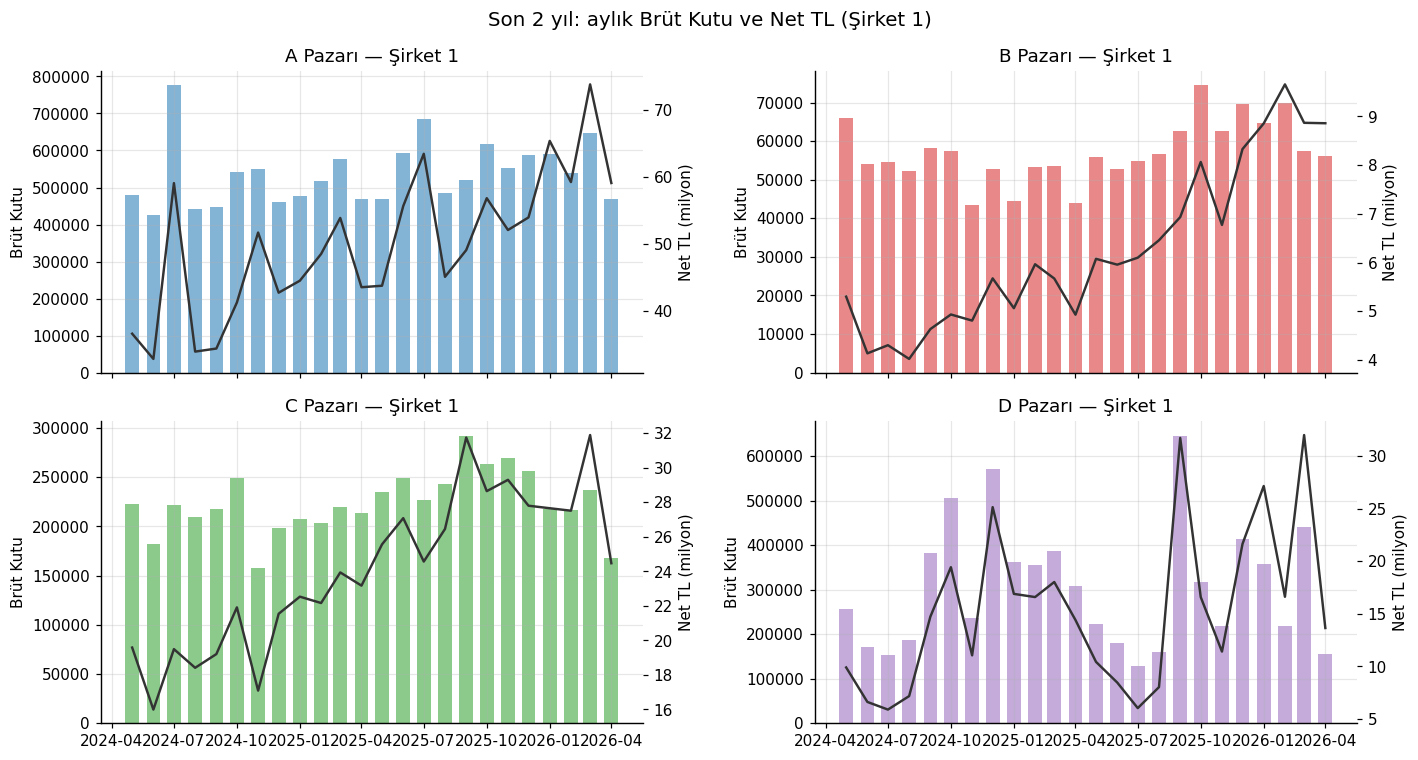

In [12]:
LAST_TWO_YEARS_START = pd.Timestamp("2024-05-01")
company_one = df[df.sirket == "Şirket 1"]
last_two_years = company_one[company_one.tarih >= LAST_TWO_YEARS_START]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for axis, market in zip(axes.ravel(), MARKETS, strict=True):
    g = (
        last_two_years[last_two_years.pazar == market]
        .groupby("tarih", observed=True)
        .agg(gross=("brut_kutu", "sum"), net_revenue=("net_tl", "sum"))
    )
    axis.bar(g.index, g.gross, width=20, color=MARKET_COLORS[market], alpha=0.55, label="Brüt Kutu")
    second_axis = axis.twinx()
    second_axis.plot(
        g.index,
        g.net_revenue / 1e6,
        color="#333333",
        linewidth=1.6,
        label="Net TL (milyon)",
    )
    second_axis.grid(False)
    axis.set_title(f"{market} — Şirket 1")
    axis.set_ylabel("Brüt Kutu")
    second_axis.set_ylabel("Net TL (milyon)")
fig.suptitle("Son 2 yıl: aylık Brüt Kutu ve Net TL (Şirket 1)", fontsize=13)
fig.tight_layout()
save_figure(fig, "a1_pazar_bazinda_satis")
plt.show()

In [13]:
summary = last_two_years.groupby("pazar", observed=True).agg(
    brut_kutu=("brut_kutu", "sum"), net_tl=("net_tl", "sum")
)
mean_mf = last_two_years.groupby("pazar", observed=True).mf_oran_temiz.mean()
summary["birim_fiyat_ort"] = summary.net_tl / (summary.brut_kutu * (1 - mean_mf))
summary.style.format({"brut_kutu": "{:,.0f}", "net_tl": "{:,.0f}", "birim_fiyat_ort": "{:,.2f}"})

,brut_kutu,net_tl,birim_fiyat_ort
pazar,,,
A Pazarı,"12,918,121","1,200,778,640",94.85
B Pazarı,"1,372,128","150,396,579",117.88
C Pazarı,"5,378,746","577,851,376",107.47
D Pazarı,"7,335,930","369,676,206",50.81


In [14]:
# Ürün dominasyonu: her pazarda en büyük ürün hacmin yüzde kaçını taşıyor?
rows = []
for market in MARKETS:
    t = (
        last_two_years[last_two_years.pazar == market]
        .groupby("urun", observed=True)
        .brut_kutu.sum()
    )
    t = t.sort_values(ascending=False)
    t = t[t > 0]
    rows.append(
        {
            "Pazar": market,
            "Ürün sayısı": len(t),
            "En büyük ürün": t.index[0],
            "Payı (%)": round(100 * t.iloc[0] / t.sum(), 1),
            "İlk 2 ürün payı (%)": round(100 * t.iloc[:2].sum() / t.sum(), 1),
        }
    )
dominance = pd.DataFrame(rows)
dominance

,Pazar,Ürün sayısı,En büyük ürün,Payı (%),İlk 2 ürün payı (%)
0,A Pazarı,10,Ürün-G,29.1,48.4
1,B Pazarı,4,Ürün-FR,69.5,97.3
2,C Pazarı,1,Ürün 2,100.0,100.0
3,D Pazarı,2,Ürün 77,60.6,100.0


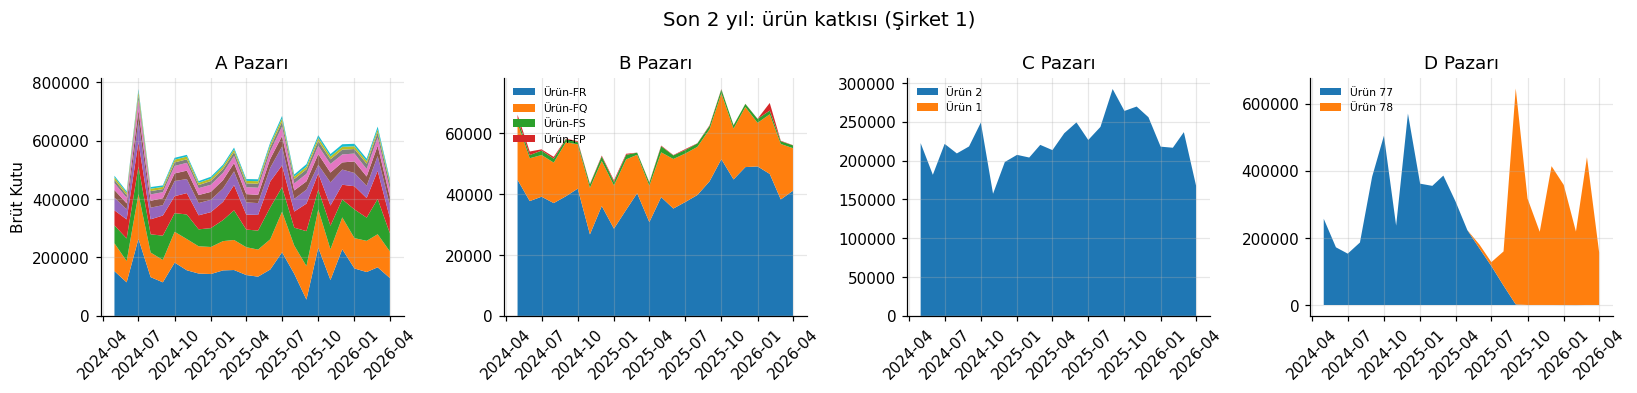

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=False)
for axis, market in zip(axes, MARKETS, strict=True):
    g = (
        last_two_years[last_two_years.pazar == market]
        .pivot_table(
            index="tarih", columns="urun", values="brut_kutu", aggfunc="sum", observed=True
        )
        .fillna(0.0)
    )
    g = g.loc[:, g.sum().sort_values(ascending=False).index]
    axis.stackplot(g.index, g.T.to_numpy(), labels=list(g.columns))
    axis.set_title(market)
    axis.tick_params(axis="x", rotation=45)
    if g.shape[1] <= 4:
        axis.legend(fontsize=7, loc="upper left")
axes[0].set_ylabel("Brüt Kutu")
fig.suptitle("Son 2 yıl: ürün katkısı (Şirket 1)", fontsize=13)
fig.tight_layout()
save_figure(fig, "a1_urun_katkisi")
plt.show()

In [16]:
# Zirve ve dip aylar: ay ortalamasının pazar ortalamasına oranı.
monthly = (
    last_two_years.groupby(["pazar", last_two_years.tarih.dt.month], observed=True)
    .brut_kutu.mean()
    .rename("ort")
)
monthly = monthly.reset_index().rename(columns={"tarih": "ay"})
monthly["endeks"] = monthly.groupby("pazar", observed=True).ort.transform(
    lambda s: 100 * s / s.mean()
)
peak_trough = pd.DataFrame(
    [
        {
            "Pazar": market,
            "Zirve ay": int(g.loc[g.endeks.idxmax(), "ay"]),
            "Zirve endeks": round(g.endeks.max(), 1),
            "Dip ay": int(g.loc[g.endeks.idxmin(), "ay"]),
            "Dip endeks": round(g.endeks.min(), 1),
        }
        for market, g in monthly.groupby("pazar", observed=True)
    ]
)
peak_trough

,Pazar,Zirve ay,Zirve endeks,Dip ay,Dip endeks
0,A Pazarı,7,135.7,8,85.9
1,B Pazarı,10,115.4,4,87.5
2,C Pazarı,10,111.8,2,91.7
3,D Pazarı,9,162.9,7,44.5


#### Teknik yorum

Dört pazar hacim olarak üç mertebe farklı değil ama **büyüklük sıralaması ciroyla
uyuşmuyor**: D Pazarı kutu bazında ikinci sırada, Net TL bazında sonuncuya yakın —
yani D'de birim fiyat belirgin şekilde düşük. Bu, A6'daki fiyat analizinin
habercisidir ve ciro ile hacmi ayrı okumak gerektiğini gösterir.

Ürün kırılımında C Pazarı bir uç durum: iki üründen biri (`Ürün 1`) son iki yılda
tek bir kutu bile satmamış, dolayısıyla hacmin **%100'ü** tek üründe. B Pazarı'nda da
tek ürün (`Ürün-FR`) hacmin ~%70'ini taşıyor. A Pazarı on ürünle en dengeli dağılıma
sahip; en büyük ürünün payı %30'un altında.

Zirve/dip endeksleri burada yalnız iki yılın ortalaması — mevsimsellik iddiası için
zayıf bir temel. Asıl mevsimsellik ölçümü A3'te STL ile, 124 ayın tamamı üzerinden
yapılıyor.

#### İş yorumu

C ve B pazarlarındaki tek ürün yoğunlaşması **konsantrasyon riski**: o üründe bir
tedarik kesintisi ya da fiyat baskısı, pazarın tamamını götürür. A Pazarı'nın dengeli
portföyü bu açıdan sağlıklı. D Pazarı'nda hacim yüksek ama ciro düşük — buradaki
işin kârlılığı ayrıca sorgulanmalı (A6'daki birim fiyat ve promosyon maliyeti
tablosuyla birlikte okunmalı).

---
## A2 — Pazar payları ve rekabet pozisyonu

Paylar `Brüt Kutu` üzerinden, pazar-ay bazında hesaplanıyor. Üç oyuncu: Şirket 1
(ana firma), Şirket 2 (doğrudan rakip), Diğer Şirket (pazardaki diğer tüm firmalar).

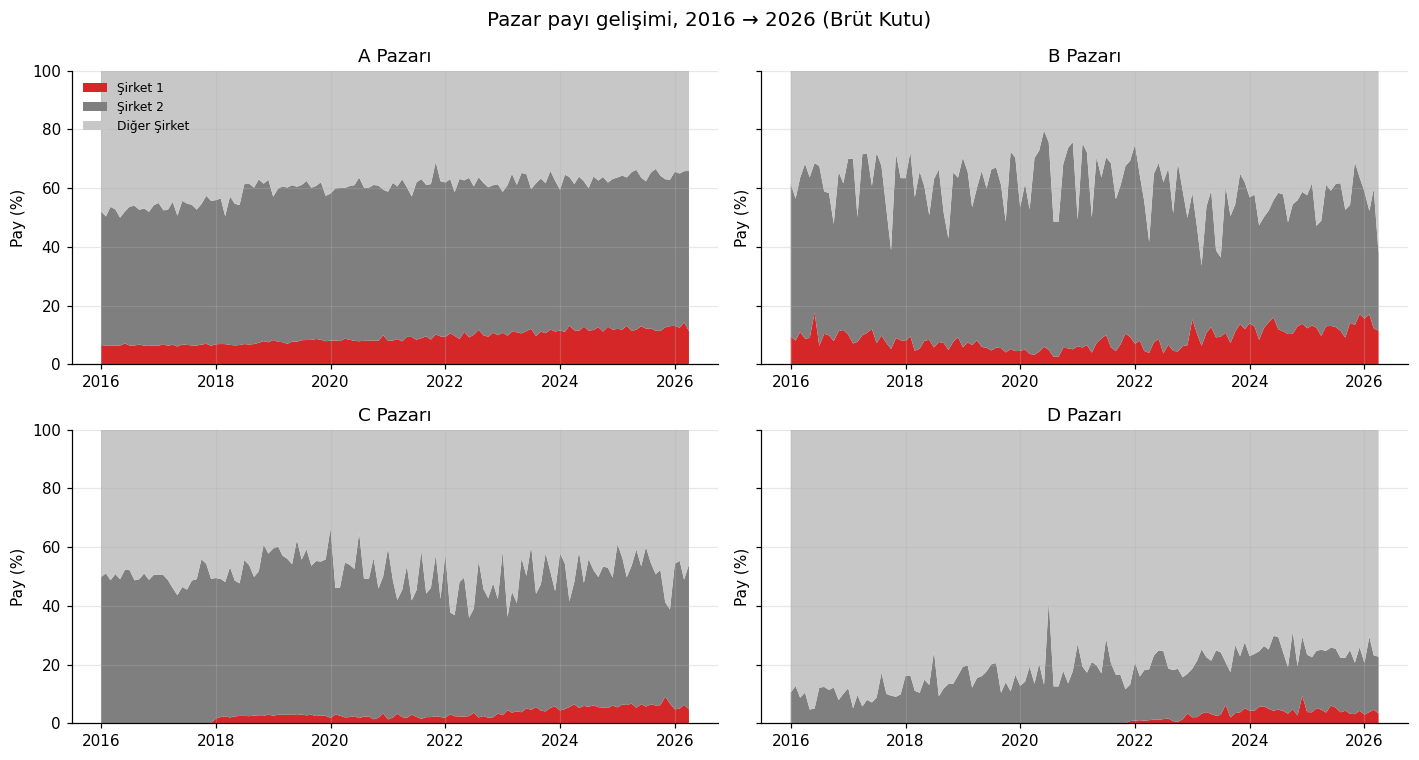

In [17]:
shares = market_share(df)

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey=True)
for axis, market in zip(axes.ravel(), MARKETS, strict=True):
    g = shares[shares.pazar == market].pivot_table(
        index="tarih", columns="sirket", values="pay", observed=True
    )
    order = [s for s in ["Şirket 1", "Şirket 2", "Diğer Şirket"] if s in g.columns]
    g = g[order].fillna(0.0)
    axis.stackplot(g.index, g.T.to_numpy(), labels=order, colors=[COMPANY_COLORS[s] for s in order])
    axis.set_title(market)
    axis.set_ylim(0, 100)
    axis.set_ylabel("Pay (%)")
axes[0, 0].legend(loc="upper left", fontsize=8)
fig.suptitle("Pazar payı gelişimi, 2016 → 2026 (Brüt Kutu)", fontsize=13)
fig.tight_layout()
save_figure(fig, "a2_pazar_paylari")
plt.show()

In [18]:
# 2016 ve last 12 ay payları yan yana — değişimin yönü.
first_year = (
    shares[shares.tarih.dt.year == 2016].groupby(["pazar", "sirket"], observed=True).pay.mean()
)
last_year = (
    shares[shares.tarih >= shares.tarih.max() - pd.DateOffset(months=11)]
    .groupby(["pazar", "sirket"], observed=True)
    .pay.mean()
)
comparison = pd.concat([first_year.rename("2016 (%)"), last_year.rename("Son 12 ay (%)")], axis=1)
comparison["Değişim (puan)"] = comparison["Son 12 ay (%)"] - comparison["2016 (%)"]
comparison.round(1)

2016 (%)  Son 12 ay (%)  Değişim (puan)
pazar    sirket                                               
A Pazarı Diğer Şirket      47.5           35.3           -12.2
         Şirket 1           6.5           12.4             5.9
         Şirket 2          46.0           52.3             6.3
B Pazarı Diğer Şirket      38.2           42.4             4.2
         Şirket 1          10.1           13.3             3.2
         Şirket 2          51.7           44.3            -7.4
C Pazarı Diğer Şirket      49.8           48.1            -1.7
         Şirket 2          50.2           45.9            -4.3
D Pazarı Diğer Şirket      90.2           76.0           -14.2
         Şirket 2           9.8           19.9            10.1
C Pazarı Şirket 1           NaN            6.1             NaN
D Pazarı Şirket 1           NaN            4.0             NaN

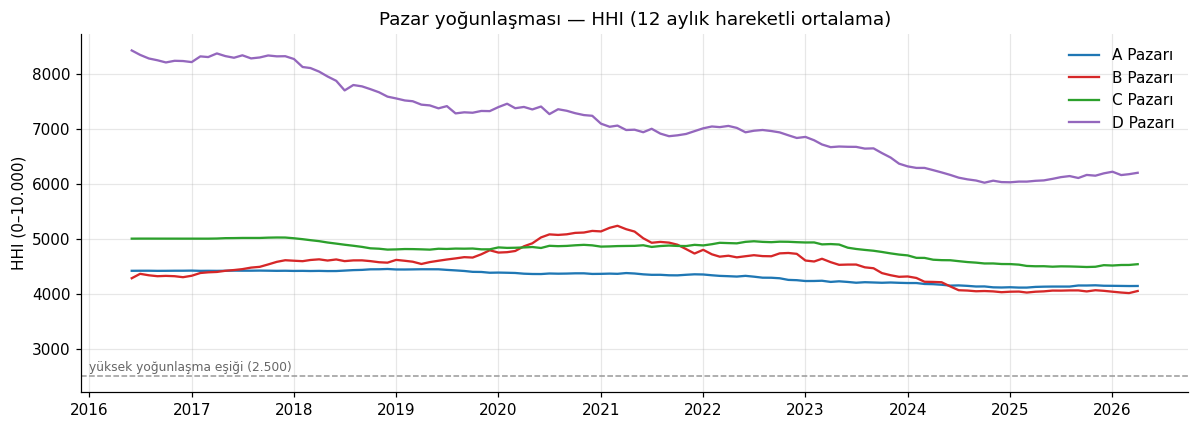

In [19]:
# HHI: pazar yoğunlaşması artıyor mu?
h = hhi(df)
fig, axis = plt.subplots(figsize=(11, 4))
for market in MARKETS:
    g = h[h.pazar == market].set_index("tarih").hhi.rolling(12, min_periods=6).mean()
    axis.plot(g.index, g, label=market, color=MARKET_COLORS[market])
axis.axhline(2500, color="#999999", linestyle="--", linewidth=1)
axis.text(h.tarih.min(), 2600, "yüksek yoğunlaşma eşiği (2.500)", fontsize=8, color="#666666")
axis.set_title("Pazar yoğunlaşması — HHI (12 aylık hareketli ortalama)")
axis.set_ylabel("HHI (0–10.000)")
axis.legend()
fig.tight_layout()
save_figure(fig, "a2_hhi")
plt.show()

In [20]:
# "Orantısız pay": pazar toplamı ne kadar büyüdü, Şirket 1 ne kadar?
# 2026 kısmi bir yıl (yalnız 4 ay) olduğu için hesap 2016–2025 tam yılları üzerinden.
# Her pazarda Şirket 1'in **kendi** varlık aralığı kullanılır: D Pazarı'nda ürünler
# 2021 ve 2025'te başlıyor, 2016'dan CAGR hesaplamak anlamsız olurdu.
def _compute_cagr(first_value: float, last_value: float, year_span: int) -> float:
    if year_span <= 0 or first_value <= 0 or last_value <= 0:
        return float("nan")
    return 100 * ((last_value / first_value) ** (1 / year_span) - 1)


rows = []
for market in MARKETS:
    g = df[df.pazar == market]
    market_yearly = g.groupby(g.tarih.dt.year, observed=True).brut_kutu.sum()
    company_yearly = (
        g[g.sirket == "Şirket 1"].groupby(g.tarih.dt.year, observed=True).brut_kutu.sum()
    )
    common_years = [
        y for y in range(2016, 2026) if market_yearly.get(y, 0) > 0 and company_yearly.get(y, 0) > 0
    ]
    if len(common_years) < 2:
        rows.append({"Pazar": market, "Aralık": "yetersiz veri"})
        continue
    first, last = common_years[0], common_years[-1]
    market_cagr = _compute_cagr(market_yearly[first], market_yearly[last], last - first)
    company_cagr = _compute_cagr(company_yearly[first], company_yearly[last], last - first)
    rows.append(
        {
            "Pazar": market,
            "Aralık": f"{first}–{last}",
            "Pazar CAGR (%)": round(market_cagr, 1),
            "Şirket 1 CAGR (%)": round(company_cagr, 1),
            "Fark (puan)": round(company_cagr - market_cagr, 1),
        }
    )
cagr_table = pd.DataFrame(rows)
cagr_table

,Pazar,Aralık,Pazar CAGR (%),Şirket 1 CAGR (%),Fark (puan)
0,A Pazarı,2016–2025,2.8,10.2,7.4
1,B Pazarı,2016–2025,0.8,3.2,2.4
2,C Pazarı,2017–2025,4.3,131.8,127.5
3,D Pazarı,2021–2025,14.1,186.5,172.4


#### Teknik yorum

Şirket 1'in payı dört pazarda da **%15'in altında**: A'da ~%12, B'de ~%13, C'de ~%6,
D'de ~%4. Yani Şirket 1 hiçbir pazarda lider değil; A ve B'de Şirket 2 açık ara önde,
C ve D'de pazarın büyük kısmı "Diğer Şirket" çatısı altındaki dağınık rekabette.

HHI dört pazarda da düşüş eğiliminde — yani **yoğunlaşma azalıyor, rekabet artıyor**.
D Pazarı 2016'da 8.240 ile neredeyse tekelci bir yapıdayken bugün 6.226'ya inmiş; en
büyük yapısal değişim orada. Yine de dört pazar da 2.500 eşiğinin çok üzerinde,
yani hepsi "yüksek yoğunlaşmalı" sayılır.

"Orantısız pay" sorusunun cevabı **evet, dört pazarda da**: Şirket 1 her pazarda
pazarın kendisinden hızlı büyümüş (A'da 10,2 vs 2,8; B'de 3,2 vs 0,8). Ama bu tablo
dikkatli okunmalı.

⚠️ **İki uyarı.** (1) 2026 kısmi bir yıl (yalnız 4 ay) olduğu için hesap 2016–2025
tam yılları üzerinden; aksi hâlde son yıl yapay olarak düşük çıkardı. (2) C Pazarı'nda
%131,8 ve D Pazarı'nda %186,5'lik CAGR **sıfıra yakın bir tabandan** geliyor:
Şirket 1 C'ye 2017'de, D'ye 2021'de girmiş ve ilk yıl hacmi çok küçük. Böyle bir
tabanda CAGR matematiksel olarak doğru ama iş anlamında yanıltıcıdır — bu yüzden
her satırda hesabın hangi aralıkta yapıldığı ayrıca yazılıyor. Pay tablosu (yukarıda)
bu büyümenin Şirket 1'i hâlâ %6 ve %4 seviyesinde bıraktığını gösteriyor.

#### İş yorumu

Şirket 1 için en gerçekçi büyüme alanı **B Pazarı**: payı görece yüksek (~%13) ve
pazar Şirket 2 ile paylaşılıyor, yani rekabet iki oyuncu arasında — pay almak için
dağınık bir kalabalıkla değil tek rakiple mücadele etmek gerekiyor. D Pazarı'nda ise
%4'lük pay ve düşük birim fiyat birlikte okunduğunda, yatırım yapılacak yer olup
olmadığı ciddi biçimde sorgulanmalı.

İyi haber: Şirket 1 dört pazarda da pazardan hızlı büyüyor, yani pay **kazanıyor**.
Kötü haber: başladığı taban o kadar düşük ki A ve B'de bile on yılda liderliğe yakın
bir yere gelememiş. C ve D'deki üç haneli büyüme oranlarını hedef olarak sunmak
yanıltıcı olur — oradaki asıl soru büyüme hızı değil, mutlak hacmin anlamlı bir
seviyeye çıkıp çıkmayacağı.

---
## A3 — Mevsimsellik

Mevsimsel indeks ve mevsimsellik gücü **STL ayrıştırmasıyla** (`robust=True`)
hesaplanıyor. Veride promosyon kaynaklı sıçramalar var; klasik ayrıştırma onlara
aşırı tepki verip mevsimselliği çarpıtıyor.

⚠️ **24 aydan az satış görmüş serilerde hesap yapılmıyor.** 12 aylık döngünün en az
iki tekrarı gerekiyor. Bu eşik satır sayısına değil **satış görülen ay** sayısına
bakıyor: `C Pazarı/Ürün 1` kırpma sonrası 28 satır taşıyor ama yalnız bir ayında
satışı var — satır sayısına bakan bir eşik bunu kabul ediyor ve STL o tek sıçramayı
"mevsimsellik gücü 0,99" diye raporluyordu. Uydurulmuş mevsimsellik, "hesaplanamadı"
demekten daha kötüdür.

In [21]:
rows = []
for (market, product), g in company_one.groupby(["pazar", "urun"], observed=True):
    series_ = g.sort_values("tarih").set_index("tarih").brut_kutu.astype(float)
    strength = seasonality_strength(series_)
    index_ = seasonal_index(series_)
    with_sales = int((series_ > 0).sum())
    rows.append(
        {
            "Pazar": market,
            "Ürün": product,
            "Satışlı ay": with_sales,
            "Mevsimsellik gücü": None if strength is None else round(strength, 3),
            "Zirve ay": None if index_ is None else int(index_.idxmax()),
            "Zirve endeksi": None if index_ is None else round(float(index_.max()), 2),
            "Not": (
                "yetersiz veri"
                if strength is None
                else ("sınırda — 3 döngüden az" if with_sales < 36 else "")
            ),
        }
    )
seasonality = pd.DataFrame(rows)
seasonality

,Pazar,Ürün,Satışlı ay,Mevsimsellik gücü,Zirve ay,Zirve endeksi,Not
0,A Pazarı,Ürün-A,124,0.481,9.0,1.19,
1,A Pazarı,Ürün-B,124,0.368,3.0,1.17,
2,A Pazarı,Ürün-C,124,0.289,7.0,1.14,
3,A Pazarı,Ürün-D,124,0.160,7.0,1.12,
4,A Pazarı,Ürün-E,124,0.235,7.0,1.14,
5,A Pazarı,Ürün-F,124,0.136,9.0,1.27,
6,A Pazarı,Ürün-G,124,0.324,7.0,1.20,
7,A Pazarı,Ürün-H,124,0.286,7.0,1.21,
8,A Pazarı,Ürün-I,124,0.304,7.0,1.22,
9,A Pazarı,Ürün-J,124,0.304,7.0,1.19,


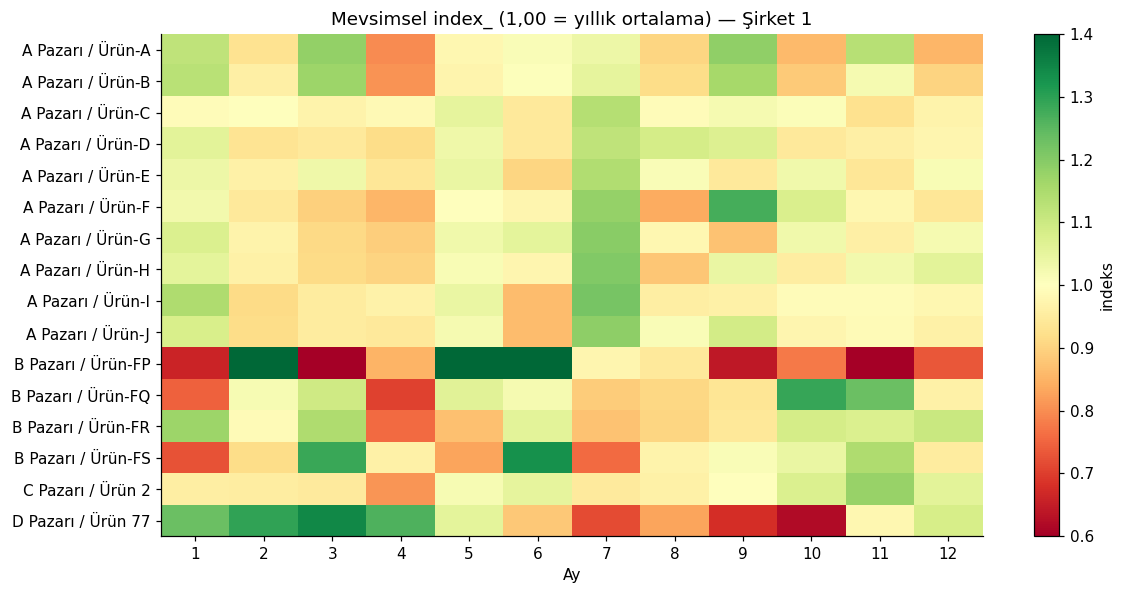

In [22]:
# Isı haritası: ürün × ay mevsimsel indeksi (yalnız hesaplanabilen seriler).
computable = [
    (
        (market, product),
        seasonal_index(g.sort_values("tarih").set_index("tarih").brut_kutu.astype(float)),
    )
    for (market, product), g in company_one.groupby(["pazar", "urun"], observed=True)
]
computable = [(k, v) for k, v in computable if v is not None]

heatmap = pd.DataFrame({f"{k[0]} / {k[1]}": v for k, v in computable}).T

fig, axis = plt.subplots(figsize=(11, 5.5))
image = axis.imshow(heatmap.to_numpy(), aspect="auto", cmap="RdYlGn", vmin=0.6, vmax=1.4)
axis.set_xticks(range(12), [str(a) for a in heatmap.columns])
axis.set_yticks(range(len(heatmap)), list(heatmap.index))
axis.set_xlabel("Ay")
axis.set_title("Mevsimsel index_ (1,00 = yıllık ortalama) — Şirket 1")
fig.colorbar(image, ax=axis, label="indeks")
axis.grid(False)
fig.tight_layout()
save_figure(fig, "a3_mevsimsellik_isi_haritasi")
plt.show()

#### Teknik yorum

**Şirket 1'in hiçbir ürününde güçlü mevsimsellik yok.** Hesaplanabilen 16 serinin
15'inde mevsimsellik gücü 0,50'nin altında; en yükseği A Pazarı/Ürün-A'da 0,48.
Hyndman ölçeğinde 0,64 üzeri "belirgin mevsimsel" sayılır — bu eşiği aşan tek seri
B Pazarı/Ürün-FP (0,997) ve o da güvenilir değil: yalnız 27 aylık geçmişi var, yani
STL'e 2,25 döngü veriliyor. Bu durum tabloda "sınırda" olarak işaretlendi.

Yine de sistematik bir örüntü var: **A Pazarı'nın on ürününden yedisinde zirve ay
Temmuz**, ikisinde Eylül. Yani A Pazarı'nda ürün bazında değil **pazar seviyesinde**
bir yaz zirvesi var ve tek tek ürünlerde zayıf görünmesinin sebebi gürültü.

🚨 **Veri gerçeğinin sınırı:** case "aynı ürünün farklı pazarlardaki örüntüsü"nü
soruyor ama Şirket 1'in ürün setleri pazarlar arası **ayrık** — A'da Ürün-A…J,
B'de FP…FS, C'de Ürün 1–2, D'de 77–78. Hiçbir ürün birden fazla pazarda yok.
Dolayısıyla bu karşılaştırma ürün seviyesinde **yapılamıyor**; analiz pazar
seviyesinde toplulaştırılmış karşılaştırmaya dönüşüyor. Bu bir eksiklik değil,
verinin yapısı.

#### İş yorumu

Mevsimsellik zayıf olduğu için **stok planlaması mevsime göre değil, promosyon
takvimine göre yapılmalı** — A4'ün gösterdiği gibi asıl dalgalanmayı MF yaratıyor,
mevsim değil. A Pazarı'ndaki Temmuz zirvesi tek eyleme dönüştürülebilir bulgu:
üretim ve kanal doldurma Mayıs–Haziran'da planlanmalı.

`C/Ürün 1` ve `D/Ürün 78` için mevsimsel hedef koymak veriye dayanmaz; bu iki ürün
için hedefler ancak birkaç yıl daha veri biriktikten sonra anlamlı olur.

---
## A4 — Mal fazlasının (MF) bir sonraki ay satışına etkisi

**Olay çalışması.** Olay = `MF Oran > %10` olan (seri, ay) çiftleri. Sonuç ölçüsü
bir sonraki ayın değişimi: `Δ = brut_kutu[t+1] / brut_kutu[t] − 1`. Kontrol grubu
aynı serilerin `MF ≤ %10` olan ayları.

İki test birlikte: **Mann-Whitney U** (dağılım varsayımı yok — Δ dağılımı çarpık) ve
**Welch t-testi** (eşit varyans varsaymıyor). Etki büyüklüğü **Cliff's delta**.
Dört pazar aynı anda test edildiği için p-değerleri **Benjamini-Hochberg FDR** ile
düzeltiliyor.

In [23]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

events = company_one.sort_values(["pazar", "urun", "tarih"]).copy()
events["sonraki"] = events.groupby(["pazar", "urun"], observed=True).brut_kutu.shift(-1)
events["delta"] = np.where(events.brut_kutu > 0, events.sonraki / events.brut_kutu - 1, np.nan)
events["yuksek_mf"] = events.mf_oran_temiz > 0.10
events = events.dropna(subset=["delta"])

print(
    f"Toplam gözlem: {len(events)}  |  "
    f"olay: {int(events.yuksek_mf.sum())}  |  "
    f"kontrol: {int((~events.yuksek_mf).sum())}"
)

Toplam gözlem: 1783  |  olay: 89  |  kontrol: 1694


In [24]:
def _cliff_delta(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sign(a[:, None] - b[None, :]).sum() / (len(a) * len(b)))


MIN_EVENTS = 5
rows = []
for market, g in events.groupby("pazar", observed=True):
    o = g[g.yuksek_mf].delta.to_numpy()
    k = g[~g.yuksek_mf].delta.to_numpy()
    row = {"Pazar": market, "Olay n": len(o), "Kontrol n": len(k)}
    if len(o) < MIN_EVENTS or len(k) < MIN_EVENTS:
        row["Sonuç"] = "test edilemedi (yetersiz events)"
        rows.append(row)
        continue
    _, p_mwu = stats.mannwhitneyu(o, k, alternative="two-sided")
    _, p_welch = stats.ttest_ind(o, k, equal_var=False)
    row.update(
        {
            "Olay medyan Δ": round(float(np.median(o)), 3),
            "Kontrol medyan Δ": round(float(np.median(k)), 3),
            "Mann-Whitney p": p_mwu,
            "Welch p": p_welch,
            "Cliff δ": round(_cliff_delta(o, k), 3),
        }
    )
    rows.append(row)

mf_test = pd.DataFrame(rows)
valid = (
    mf_test["Mann-Whitney p"].notna()
    if "Mann-Whitney p" in mf_test
    else pd.Series(False, index=mf_test.index)
)
if valid.any():
    mf_test.loc[valid, "FDR q"] = multipletests(
        mf_test.loc[valid, "Mann-Whitney p"], method="fdr_bh"
    )[1]
    mf_test["Anlamlı (q<0,05)"] = np.where(mf_test["FDR q"].notna(), mf_test["FDR q"] < 0.05, None)
mf_test

,Pazar,Olay n,Kontrol n,Olay medyan Δ,Kontrol medyan Δ,Mann-Whitney p,Welch p,Cliff δ,Sonuç,FDR q,"Anlamlı (q<0,05)"
0,A Pazarı,71,1159,-0.217,0.010,3.068583e-12,0.000514,-0.493,NaN,9.205748e-12,True
1,B Pazarı,12,379,-0.187,0.007,7.704658e-02,0.050216,-0.300,NaN,1.155699e-01,False
2,C Pazarı,0,101,NaN,NaN,NaN,NaN,NaN,test edilemedi (yetersiz events),NaN,None
3,D Pazarı,6,55,-0.205,-0.055,8.041863e-01,0.343209,0.067,NaN,8.041863e-01,False


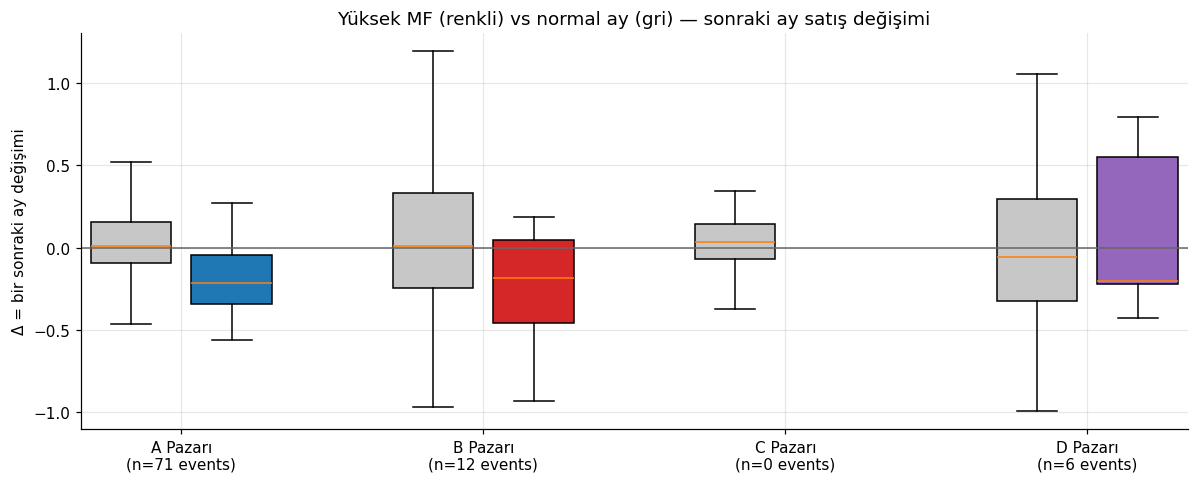

In [25]:
fig, axis = plt.subplots(figsize=(11, 4.5))
positions, labels = [], []
for i, market in enumerate(MARKETS):
    g = events[events.pazar == market]
    o = g[g.yuksek_mf].delta.to_numpy()
    k = g[~g.yuksek_mf].delta.to_numpy()
    if len(k):
        axis.boxplot(
            [k],
            positions=[i * 3],
            widths=0.8,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor="#c7c7c7"),
        )
    if len(o):
        axis.boxplot(
            [o],
            positions=[i * 3 + 1],
            widths=0.8,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor=MARKET_COLORS[market]),
        )
    positions.append(i * 3 + 0.5)
    labels.append(f"{market}\n(n={len(o)} events)")
axis.set_xticks(positions, labels)
axis.axhline(0, color="#666666", linewidth=1)
axis.set_ylabel("Δ = bir sonraki ay değişimi")
axis.set_title("Yüksek MF (renkli) vs normal ay (gri) — sonraki ay satış değişimi")
fig.tight_layout()
save_figure(fig, "a4_mf_etkisi")
plt.show()

#### Teknik yorum

**A Pazarı'nda etki net ve istatistiksel olarak anlamlı, ama işaret beklenenin
tersi.** 71 olay karşısında 1.159 kontrol ayı: yüksek MF ayını izleyen ayda medyan
değişim **−%21,7**, normal ayları izleyen ayda ise +%1,0. Mann-Whitney
p ≈ 3×10⁻¹², FDR düzeltmesinden sonra q ≈ 9×10⁻¹². Cliff's δ = −0,49, yani
orta-büyük bir etki. İki test de (dağılım varsayımsız ve parametrik) aynı yöne
işaret ediyor.

Diğer üç pazarda **anlamlı sonuç yok**: B Pazarı'nda 12 olayla q ≈ 0,12,
D Pazarı'nda 6 olayla q ≈ 0,80. C Pazarı'nda Şirket 1 hiçbir ayda %10 üzeri MF
kullanmamış, dolayısıyla test edilecek olay yok — bu satır "test edilemedi" olarak
raporlanıyor, sıfır etki olarak değil.

⚠️ Ortalama yerine **medyan** raporlanıyor: D Pazarı'nda ortalama Δ 7,6 çıkıyor ama
bu, paydası çok küçük birkaç aydan kaynaklanan bir artefakt. Küçük hacimli serilerde
oransal değişim patlıyor.

⚠️ Bu bir **korelasyon** bulgusudur, nedensellik değil. Yüksek MF'in kendisi satışı
düşürüyor olabileceği gibi, satışın zaten düşeceği aylarda MF artırılıyor da olabilir.
Case "istatistiksel olarak anlamlı" diyor, "nedensel etki" demiyor.

#### İş yorumu

A Pazarı'ndaki bulgu klasik **kanal doldurma (pull-forward)** örüntüsü: yüksek mal
fazlası verildiği ay kanal doluyor, ertesi ay sipariş düşüyor. Yani MF talep
yaratmıyor, talebi öne çekiyor. Bu, promosyonun maliyetini (A6'daki TL kaybı) ek bir
hacim getirisiyle karşılamadığı anlamına gelir.

Aksiyon: A Pazarı'nda yüksek MF kampanyaları **iki aylık pencerede** değerlendirilmeli;
tek ayın satış rakamına bakarak "kampanya işe yaradı" demek yanıltıcı. B ve D
pazarlarında olay sayısı karar vermek için yetersiz — burada önce daha fazla veri
toplanmalı.

---
## A5 — Şirket 1 ile Şirket 2'nin karşılaştırması

Üç ayrı kanıt hattı: (1) yıllık büyüme, (2) rekabet yoğunluğu, (3) "Diğer Şirket
hacim kaybediyor mu?" sorusunun **veriyle sınanması** — iddia edilmesi değil.

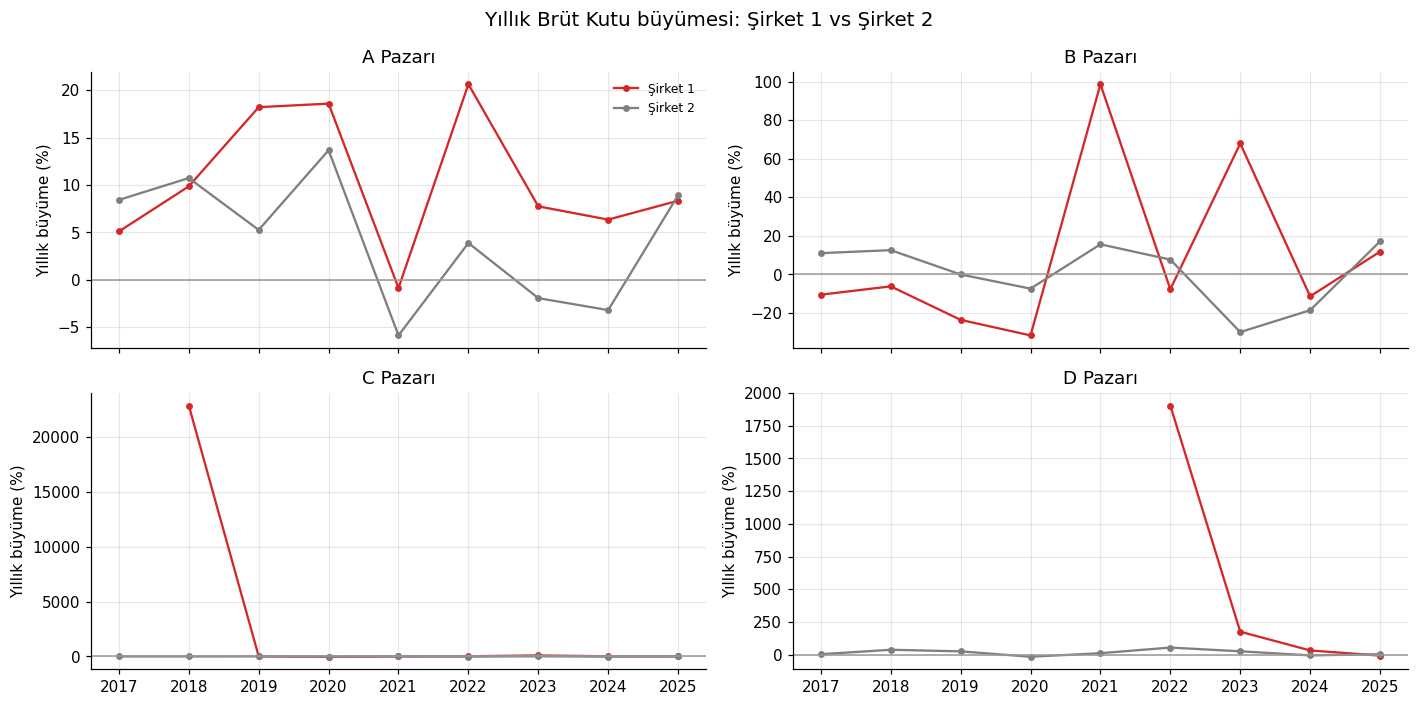

In [26]:
growth = yoy_growth(df)
growth = growth[growth.sirket.isin(["Şirket 1", "Şirket 2"]) & growth.yil.between(2017, 2025)]

fig, axes = plt.subplots(2, 2, figsize=(13, 6.5), sharex=True)
for axis, market in zip(axes.ravel(), MARKETS, strict=True):
    g = growth[growth.pazar == market]
    for company in ["Şirket 1", "Şirket 2"]:
        h = g[g.sirket == company]
        axis.plot(
            h.yil,
            h.buyume,
            marker="o",
            markersize=3.5,
            label=company,
            color=COMPANY_COLORS[company],
        )
    axis.axhline(0, color="#999999", linewidth=1)
    axis.set_title(market)
    axis.set_ylabel("Yıllık büyüme (%)")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Yıllık Brüt Kutu büyümesi: Şirket 1 vs Şirket 2", fontsize=13)
fig.tight_layout()
save_figure(fig, "a5_yillik_buyume")
plt.show()

In [27]:
# Kanıt 1: Diğer Şirket'in MUTLAK hacim trendi — doğrusal regresyon eğimi ve p-değeri.
rows = []
for market, g in df[df.sirket == "Diğer Şirket"].groupby("pazar", observed=True):
    monthly = g.groupby("tarih", observed=True).brut_kutu.sum().sort_index()
    outcome = stats.linregress(np.arange(len(monthly)), monthly.to_numpy())
    rows.append(
        {
            "Pazar": market,
            "Eğim (kutu/ay)": round(outcome.slope, 0),
            "p": outcome.pvalue,
            "R²": round(outcome.rvalue**2, 3),
            "Yön": "artıyor" if outcome.slope > 0 else "azalıyor",
            "Anlamlı (p<0,05)": outcome.pvalue < 0.05,
        }
    )
other_trend = pd.DataFrame(rows)
other_trend

,Pazar,Eğim (kutu/ay),p,R²,Yön,"Anlamlı (p<0,05)"
0,A Pazarı,-551.0,4.590958e-01,0.005,azalıyor,False
1,B Pazarı,435.0,5.480062e-02,0.030,artıyor,False
2,C Pazarı,6066.0,1.599667e-15,0.407,artıyor,True
3,D Pazarı,17863.0,2.603654e-03,0.072,artıyor,True


In [28]:
# Kanıt 2 ve 3: pay değişimi ve tutarlılık kontrolü.
# Bir şirketin o yıl pazarda hiç bulunmaması payının 0 olması demektir — bu yüzden
# eksik değerler 0 ile dolduruluyor. Doldurulmazsa üç şirketin pay değişimi toplamı
# sıfır çıkmıyor (C ve D pazarlarında Şirket 1 2016'da henüz yok).
first_year_share = (
    market_share(df)[lambda t: t.tarih.dt.year == 2016]
    .groupby(["pazar", "sirket"], observed=True)
    .pay.mean()
)
last_year_share = (
    market_share(df)[lambda t: t.tarih >= t.tarih.max() - pd.DateOffset(months=11)]
    .groupby(["pazar", "sirket"], observed=True)
    .pay.mean()
)
share_change = (
    last_year_share.unstack().fillna(0.0) - first_year_share.unstack().fillna(0.0)
).round(2)
share_change["Toplam (≈0 olmalı)"] = share_change.sum(axis=1).round(6)
share_change

sirket,Diğer Şirket,Şirket 1,Şirket 2,Toplam (≈0 olmalı)
pazar,,,,
A Pazarı,-12.17,5.91,6.27,0.01
B Pazarı,4.21,3.22,-7.43,0.00
C Pazarı,-1.75,6.07,-4.32,0.00
D Pazarı,-14.15,4.04,10.11,0.00


#### Teknik yorum

🚨 **Case'in "Diğer Şirket hacim kaybediyor" varsayımı mutlak hacimde doğrulanmıyor.**
Regresyon tablosu bunu açıkça gösteriyor: C Pazarı'nda +6.066 kutu/ay (p ≈ 1,6×10⁻¹⁵)
ve D Pazarı'nda +17.863 kutu/ay (p ≈ 0,003) ile **anlamlı biçimde artıyor**.
A Pazarı'nda eğim negatif ama anlamsız (p = 0,46, R² = 0,005) — yani orada da mutlak
bir kayıp kanıtlanamıyor.

Kayıp **pay** düzeyinde gerçek: A Pazarı'nda Diğer Şirket 12,2 puan, D Pazarı'nda
14,2 puan kaybetmiş. Yani pazarlar büyüyor, Diğer Şirket de büyüyor ama pazardan
**daha yavaş**. İki ifade birbirinin yerine kullanılamaz ve karıştırıldığında yanlış
stratejik sonuç üretir.

Payın kime gittiği tutarlılık kontrolüyle doğrulanıyor: her pazarda üç şirketin pay
değişimi toplamı **0**. A Pazarı'nda Diğer Şirket'in kaybettiği 12,2 puanı
Şirket 1 (+5,9) ve Şirket 2 (+6,3) neredeyse eşit paylaşmış. D Pazarı'ndaki 14,2
puanın büyük kısmını (+10,1) Şirket 2 almış.

⚠️ Pay hesabında eksik değerler 0 ile dolduruldu: bir şirketin o yıl pazarda hiç
bulunmaması "veri yok" değil, "payı %0" demektir. Doldurulmasaydı C ve D'de toplam
sıfır çıkmaz, tutarlılık kontrolü sahte biçimde başarısız görünürdü.

#### İş yorumu

A Pazarı Şirket 1 için en başarılı hikâye: on yılda 5,9 puan pay kazanmış ve bunu
doğrudan pazar liderinden değil, dağınık rekabetten almış. D Pazarı ise uyarı
işareti — orada da pay boşalmış ama boşluğu **Şirket 2 kapmış**, Şirket 1 değil.
D'de rakip daha agresif davranmış.

Rekabet yoğunluğu (A2'deki HHI) dört pazarda da düşüyor, yani pazarlar
parçalanıyor. Bu Şirket 1 gibi küçük paylı bir oyuncu için fırsat: liderin
konumu zayıflıyor.

---
## A6 — Birim fiyat trendi ve promosyonun maliyeti

`Birim Fiyat = Net TL / Net Kutu`, `Net Kutu = Brüt Kutu × (1 − MF Oran)`.
Bu bölümün tamamı MF ölçek düzeltmesine bağlı — düzeltme olmadan B Pazarı'nda
birim fiyat negatif çıkıyor ve tablo anlamsız oluyor.

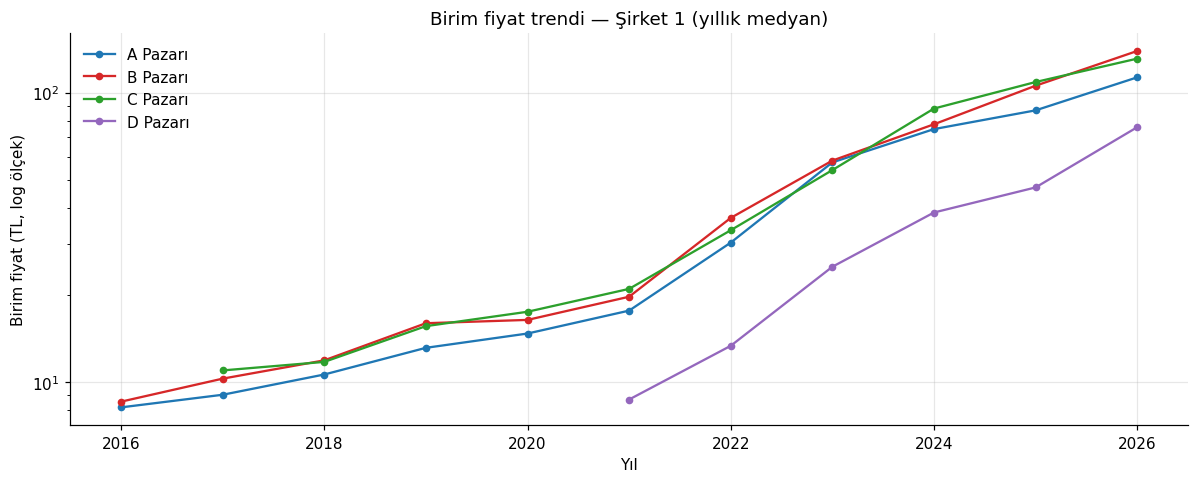

pazar,A Pazarı,B Pazarı,C Pazarı,D Pazarı
yil,,,,
2016,8.18,8.56,NaN,NaN
2017,9.04,10.28,10.97,NaN
2018,10.62,11.89,11.74,NaN
2019,13.13,15.97,15.60,NaN
2020,14.71,16.39,17.49,NaN
2021,17.65,19.71,20.98,8.70
2022,30.31,36.89,33.45,13.34
2023,57.36,58.19,53.96,25.01
2024,74.75,77.66,88.01,38.51


In [29]:
company_one_price = company_one.copy()
company_one_price["yil"] = company_one_price.tarih.dt.year
yearly_price = (
    company_one_price[company_one_price.birim_fiyat.notna()]
    .groupby(["pazar", "yil"], observed=True)
    .birim_fiyat.median()
    .unstack(0)
)

fig, axis = plt.subplots(figsize=(11, 4.5))
for market in MARKETS:
    if market in yearly_price.columns:
        axis.plot(
            yearly_price.index,
            yearly_price[market],
            marker="o",
            markersize=4,
            label=market,
            color=MARKET_COLORS[market],
        )
axis.set_yscale("log")
axis.set_ylabel("Birim fiyat (TL, log ölçek)")
axis.set_xlabel("Yıl")
axis.set_title("Birim fiyat trendi — Şirket 1 (yıllık medyan)")
axis.legend()
fig.tight_layout()
save_figure(fig, "a6_birim_fiyat")
plt.show()

yearly_price.round(2)

In [30]:
# Pazarlar arası fiyat farkı — aynı ürün birden fazla pazarda olmadığı için
# karşılaştırma pazar seviyesinde yapılıyor (A3'teki aynı veri gerçeği).
last_year = company_one_price[
    (company_one_price.yil == 2025) & company_one_price.birim_fiyat.notna()
]
price_summary = last_year.groupby("pazar", observed=True).birim_fiyat.agg(
    ["median", "std", "count"]
)
price_summary["CV"] = (price_summary["std"] / price_summary["median"]).round(3)
price_summary.round(2)

,median,std,count,CV
pazar,,,,
A Pazarı,86.76,39.76,120,0.46
B Pazarı,105.54,50.22,47,0.48
C Pazarı,108.68,0.00,12,0.00
D Pazarı,47.01,11.34,19,0.24


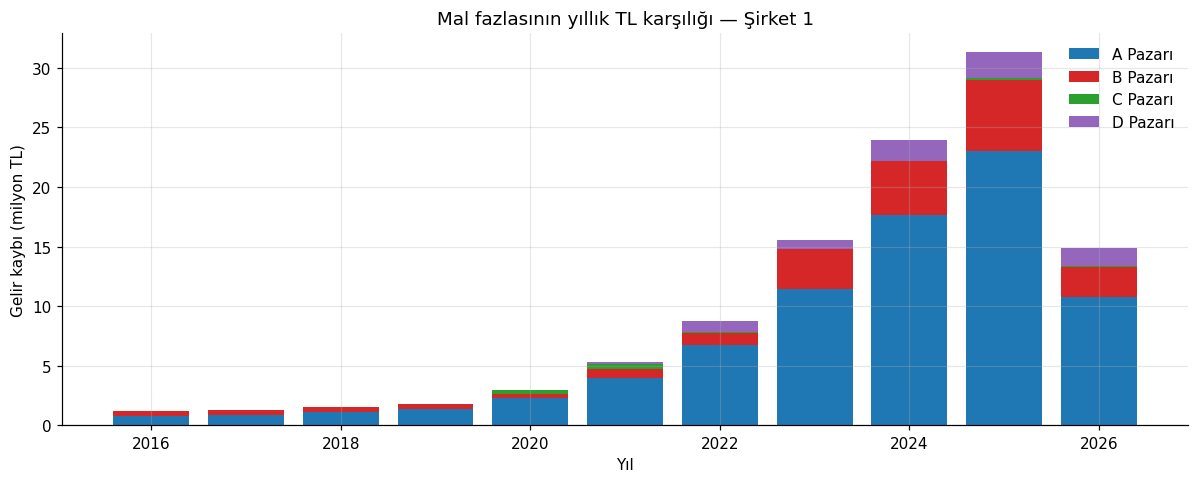

pazar,A Pazarı,B Pazarı,C Pazarı,D Pazarı
yil,,,,
2016,0.8,0.4,NaN,NaN
2017,0.9,0.4,0.0,NaN
2018,1.1,0.4,0.0,NaN
2019,1.4,0.4,0.0,NaN
2020,2.3,0.3,0.3,NaN
2021,3.9,0.8,0.4,0.1
2022,6.7,1.1,0.0,0.9
2023,11.4,3.3,0.1,0.7
2024,17.7,4.5,0.0,1.7


In [31]:
# Promosyonun TL karşılığı: bedava verilen kutular × birim fiyat.
loss = promo_revenue_loss(company_one_price)
yearly_loss = loss.groupby(["yil", "pazar"], observed=True).gelir_kaybi_tl.sum().unstack() / 1e6

fig, axis = plt.subplots(figsize=(11, 4.5))
bottom = np.zeros(len(yearly_loss))
for market in MARKETS:
    if market in yearly_loss.columns:
        value = yearly_loss[market].fillna(0.0).to_numpy()
        axis.bar(yearly_loss.index, value, bottom=bottom, label=market, color=MARKET_COLORS[market])
        bottom = bottom + value
axis.set_ylabel("Gelir kaybı (milyon TL)")
axis.set_xlabel("Yıl")
axis.set_title("Mal fazlasının yıllık TL karşılığı — Şirket 1")
axis.legend()
fig.tight_layout()
save_figure(fig, "a6_promosyon_maliyeti")
plt.show()

yearly_loss.round(1)

In [32]:
total_loss = loss.gelir_kaybi_tl.sum()
total_revenue = company_one_price.net_tl.sum()
print(f"Toplam promosyon gelir kaybı (2016–2026): {tr_number(total_loss / 1e6, 1)} milyon TL")
print(f"Aynı dönemde toplam Net TL:              {tr_number(total_revenue / 1e6, 1)} milyon TL")
print(f"Cironun yüzdesi olarak promosyon:        %{tr_number(100 * total_loss / total_revenue, 2)}")

Toplam promosyon gelir kaybı (2016–2026): 108,3 milyon TL
Aynı dönemde toplam Net TL:              3.695,3 milyon TL
Cironun yüzdesi olarak promosyon:        %2,93


#### Teknik yorum

Birim fiyat on yılda dört pazarda da yaklaşık **on katına** çıkmış: A'da 8,2 → 86,8 TL,
B'de 8,6 → 105,5 TL (2016 → 2025 medyan). Bu büyüklük TL enflasyonuyla tutarlı ve aynı
zamanda MF ölçek düzeltmesinin doğruluğunun bağımsız bir kontrolü: düzeltme yanlış
olsaydı B Pazarı bu bandın tamamen dışına düşerdi.

**D Pazarı belirgin biçimde ucuz:** 2025 medyanı 47,0 TL, diğer üç pazarın yarısı
kadar. A1'deki "D'de hacim yüksek, ciro düşük" gözleminin sayısal karşılığı bu.

Promosyonun on yıllık toplam maliyeti **108,3 milyon TL**, aynı dönem cirosunun
yaklaşık **%2,9'u**. Yük ağırlıkla A Pazarı'nda ve son yıllarda hızla artıyor
(2016'da 0,8 milyon TL, 2025'te 23,0 milyon TL).

⚠️ **Sınırlılık:** veri setinde TÜFE yok, dolayısıyla bütün fiyat trendleri
**nominal**. Reel fiyat artışı bundan belirgin biçimde düşük olacaktır; "fiyatlar on
kat arttı" ifadesi enflasyon düzeltmesi yapılmadan bir kârlılık kanıtı değildir.

#### İş yorumu

A4 ile birlikte okunduğunda promosyon politikası sorunlu görünüyor: A Pazarı'nda
yüksek MF ayını izleyen ay satış medyanda %21,7 düşüyor (yani ek talep yaratılmıyor,
talep öne çekiliyor) ve bunun bedeli yılda 23 milyon TL'ye ulaşmış durumda. Bu iki
bulgu birlikte **promosyon bütçesinin geri dönüşünü sorgulamak için yeterli**.

Somut öneri: A Pazarı'nda MF oranını kademeli olarak düşüren bir pilot çalışma —
etkisi tek ayda değil, iki aylık pencerede ölçülmeli. D Pazarı'nda ise sorun
promosyon değil fiyat konumlandırması; oradaki düşük birim fiyat, pazarın kendisinin
mi ucuz olduğu yoksa Şirket 1'in mi ucuza sattığı sorusunu gerektiriyor.

---
## A7 — Bir sonraki ay talep tahmini

**Hedef:** Şirket 1'in her ürün-pazar serisi için t+1 ayının `Brüt Kutu` değeri.

**Değerlendirme:** genişleyen pencereli **walk-forward**, son 12 ay, her adımda bir ay
ileri. Zaman serisinde tek bir train/test bölmesi yanıltıcıdır — tek bir aya denk
gelen şans model sıralamasını değiştirebilir. Beş model **aynı katmanlarda**
karşılaştırılıyor.

| Model | Tanım |
|---|---|
| `naive` | ŷ(t+1) = y(t) |
| `snaive` | ŷ(t+1) = y(t−11) — mevsimsel taban çizgisi |
| `ma3` | son üç ayın ortalaması |
| `lgbm` | global LightGBM (tüm seriler tek modelde), MF özellikleriyle |
| `lgbm_no_mf` | aynı model, MF özellikleri çıkarılmış → **ablasyon** |

In [33]:
import time

started = time.perf_counter()
predictions = {
    "naive": walk_forward(company_one, naive),
    "snaive": walk_forward(company_one, snaive),
    "ma3": walk_forward(company_one, ma3),
    "lgbm": lgbm_walk_forward(company_one, with_mf=True),
    "lgbm_no_mf": lgbm_walk_forward(company_one, with_mf=False),
}
elapsed = time.perf_counter() - started

# Ablasyonun adil olması için iki modelin aynı hedef aylarda değerlendirildiğini doğrula.
key_columns = ["pazar", "urun", "tarih"]
assert predictions["lgbm"][key_columns].equals(predictions["lgbm_no_mf"][key_columns])

print(f"Beş model {len(predictions['naive'])} tahmin üzerinde değerlendirildi ({elapsed:.1f} sn).")

Beş model 209 tahmin üzerinde değerlendirildi (15.5 sn).


In [34]:
tables = []
for name, outcome in predictions.items():
    m = metrics_by_market(outcome)
    m.insert(0, "model", name)
    tables.append(m)
metric_table = pd.concat(tables, ignore_index=True)

# Case'in istediği tablo: model × pazar → MAE, MAPE, RMSE (+ sıfır-dayanıklı WAPE).
metric_table.pivot_table(
    index="pazar", columns="model", values=["mae", "mape", "rmse", "wape"]
).round(1)

mae                                           mape                                             rmse                      \
model        lgbm lgbm_no_mf      ma3    naive    snaive    lgbm lgbm_no_mf      ma3   naive     snaive      lgbm lgbm_no_mf      ma3   
pazar                                                                                                                                   
A Pazarı  10006.7    11268.0  11767.2  16411.2    9503.1    13.1       15.1     16.7    22.2       17.3   21854.9    24728.5  22348.4   
B Pazarı   1798.0     1986.2   1653.1   2015.2    3071.6    25.4       39.6     62.1    62.7      101.7    3201.5     3677.1   2934.1   
C Pazarı  22376.8    17033.4  11884.0  12502.8   19324.0    18.9       14.7     10.6    11.2       15.7   35507.6    28256.1  21129.2   
D Pazarı  67105.5    79508.1  67714.0  70916.0  247325.1  2067.9     3528.7  30515.4  1602.3  4257901.7  106959.0   131060.4  89990.5   

                              wape                                
model        naive    snaive  lgbm lgbm_no_mf   ma3 naive snaive  
pazar                                                             
A Pazarı   30899.2   16420.1  17.8       20.0  20.9  29.2   16.9  
B Pazarı    3119.8    5561.9  11.7       12.9  10.8  13.1   20.0  
C Pazarı   21853.7   35471.8  18.7       14.2   9.9  10.4   16.1  
D Pazarı  111232.0  296346.1  52.9       62.7  53.4  55.9  195.0

In [35]:
# WAPE tek başına — model seçimi bu tablodan okunur.
wape_table = metric_table.pivot_table(index="pazar", columns="model", values="wape").round(1)
wape_table["En iyi model"] = wape_table.idxmin(axis=1)
wape_table

model,lgbm,lgbm_no_mf,ma3,naive,snaive,En iyi model
pazar,,,,,,
A Pazarı,17.8,20.0,20.9,29.2,16.9,snaive
B Pazarı,11.7,12.9,10.8,13.1,20.0,ma3
C Pazarı,18.7,14.2,9.9,10.4,16.1,ma3
D Pazarı,52.9,62.7,53.4,55.9,195.0,lgbm


🚨 **MAPE'nin neden tek başına kullanılamayacağı yukarıdaki tabloda görülüyor:**
D Pazarı'nda `snaive` için MAPE **4.257.901** çıkıyor. Sebep sıfıra yakın gerçek
değerler — küçük hacimli aylarda oransal hata patlıyor. Aynı satırda WAPE 195,0 ve
bu okunabilir bir sayı. Case MAPE istediği için tabloda duruyor, ama model seçimi
**WAPE** üzerinden yapılıyor.

In [36]:
# MF ablasyonu: MF özellikleri tahmin gücünü artırıyor mu?
ablation = wape_table[["lgbm", "lgbm_no_mf"]].copy()
ablation["WAPE farkı (puan)"] = (ablation.lgbm_no_mf - ablation.lgbm).round(1)
ablation["MF katkısı"] = np.where(
    ablation["WAPE farkı (puan)"] > 0, "iyileştiriyor", "iyileştirmiyor"
)
ablation

model,lgbm,lgbm_no_mf,WAPE farkı (puan),MF katkısı
pazar,,,,
A Pazarı,17.8,20.0,2.2,iyileştiriyor
B Pazarı,11.7,12.9,1.2,iyileştiriyor
C Pazarı,18.7,14.2,-4.5,iyileştirmiyor
D Pazarı,52.9,62.7,9.8,iyileştiriyor


In [37]:
# Mevsimsellik gücüne göre model sıralaması: aynı mimari her seride geçerli mi?
strength_map = {
    (row["Pazar"], row["Ürün"]): row["Mevsimsellik gücü"] for _, row in seasonality.iterrows()
}
rows = []
for name, outcome in predictions.items():
    labelled = outcome.copy()
    labelled["guc"] = [
        strength_map.get((p, u)) for p, u in zip(labelled.pazar, labelled.urun, strict=True)
    ]
    labelled = labelled[labelled.guc.notna()]
    split = np.where(labelled.guc >= 0.30, "güçlü (≥0,30)", "zayıf (<0,30)")
    for label_, bottom in labelled.groupby(split):
        rows.append(
            {
                "model": name,
                "Mevsimsellik": label_,
                "WAPE": round(
                    100 * (bottom.gercek - bottom.tahmin).abs().sum() / bottom.gercek.sum(), 1
                ),
            }
        )
pd.DataFrame(rows).pivot_table(index="Mevsimsellik", columns="model", values="WAPE")

model,lgbm,lgbm_no_mf,ma3,naive,snaive
Mevsimsellik,,,,,
"güçlü (≥0,30)",20.2,22.0,23.3,32.7,17.5
"zayıf (<0,30)",19.5,20.2,21.8,17.6,70.4


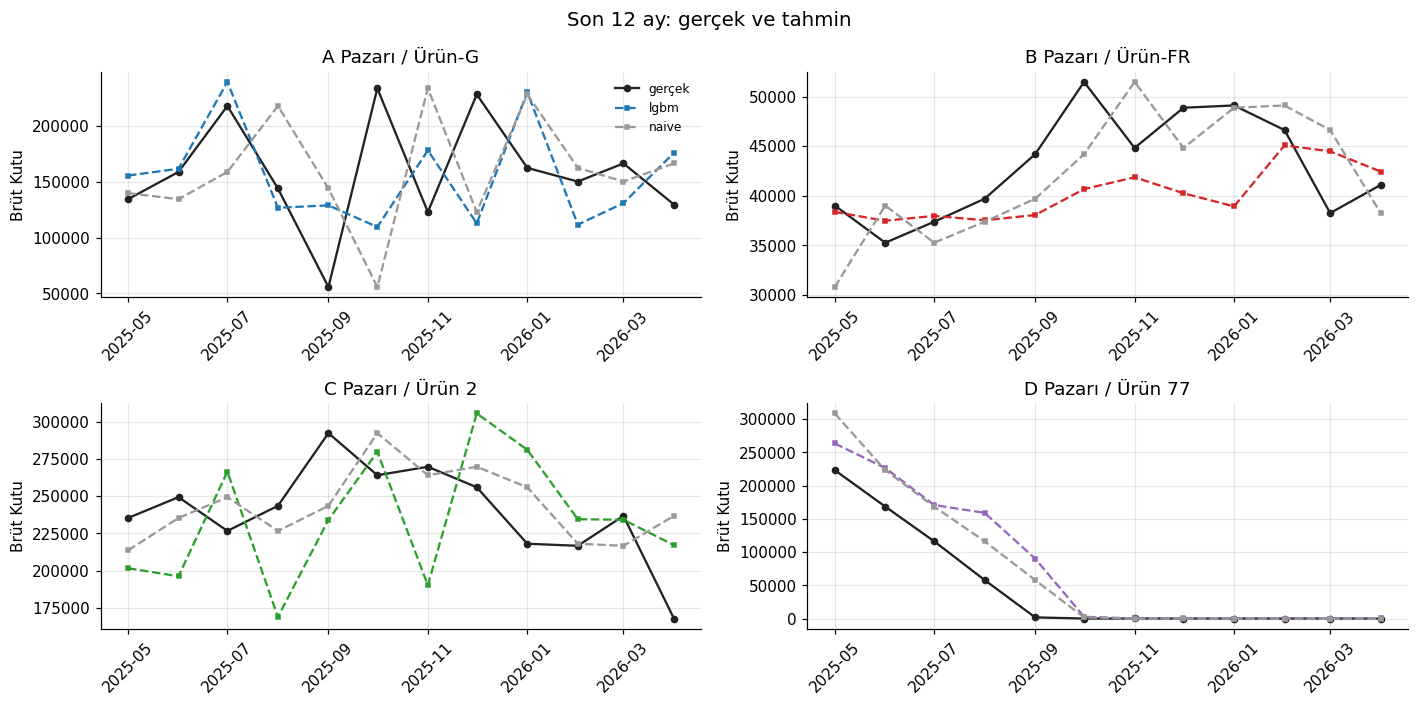

In [38]:
# Gerçek vs tahmin — her pazardan bir temsili seri.
sample_series = [
    ("A Pazarı", "Ürün-G"),
    ("B Pazarı", "Ürün-FR"),
    ("C Pazarı", "Ürün 2"),
    ("D Pazarı", "Ürün 77"),
]


def _one_series(frame, market, product):
    return frame[(frame.pazar == market) & (frame.urun == product)].sort_values("tarih")


fig, axes = plt.subplots(2, 2, figsize=(13, 6.5))
for axis, (market, product) in zip(axes.ravel(), sample_series, strict=True):
    observed = _one_series(predictions["naive"], market, product)
    axis.plot(
        observed.tarih, observed.gercek, marker="o", markersize=4, color="#222222", label="gerçek"
    )
    for name, colour in [("lgbm", MARKET_COLORS[market]), ("naive", "#999999")]:
        line = _one_series(predictions[name], market, product)
        axis.plot(
            line.tarih,
            line.tahmin,
            linestyle="--",
            marker="s",
            markersize=3,
            color=colour,
            label=name,
        )
    axis.set_title(f"{market} / {product}")
    axis.tick_params(axis="x", rotation=45)
    axis.set_ylabel("Brüt Kutu")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Son 12 ay: gerçek ve tahmin", fontsize=13)
fig.tight_layout()
save_figure(fig, "a7_gercek_vs_tahmin")
plt.show()

In [39]:
# Kısa seri politikası: bunlar tahmin edilmiyor ama global modelin eğitim havuzunda.
predicted_keys = set(zip(predictions["lgbm"].pazar, predictions["lgbm"].urun, strict=True))
all_keys = set(zip(company_one.pazar.astype(str), company_one.urun, strict=True))
pd.DataFrame(
    [
        {
            "Pazar": p,
            "Ürün": u,
            "Satışlı ay": int(
                (
                    company_one[(company_one.pazar == p) & (company_one.urun == u)].brut_kutu > 0
                ).sum()
            ),
            "Durum": "yetersiz geçmiş — tahmin edilmedi",
        }
        for p, u in sorted(all_keys - predicted_keys)
    ]
)

""


#### Teknik yorum

🚨 **Case'in "aynı model mimarisi tüm pazarlarda geçerli mi?" sorusunun cevabı: hayır.**
WAPE tablosu dört pazarda **üç farklı kazanan** gösteriyor:

| Pazar | En iyi | WAPE | Neden |
|---|---|---|---|
| A | `snaive` | 16,9 | 124 aylık tam geçmiş + A2'de görülen Temmuz zirvesi; mevsimsel taban çizgisi yeterli |
| B | `ma3` | 10,8 | Mevsimsellik zayıf, seri düzgün; basit yumuşatma en iyisi |
| C | `ma3` | 9,9 | Tek aktif ürün, düşük varyans |
| D | `lgbm` | 52,9 | Kısa ve düzensiz seriler; global model diğer pazarlardan öğrenerek fark yaratıyor |

`lgbm` hiçbir pazarda açık ara kazanmıyor ama **hiçbirinde de kötü değil** — A'da
ikinci, B'de ikinci, D'de birinci. Tek bir model seçmek gerekseydi `lgbm` en
savunulabilir tercih olurdu; pazar bazında seçim serbestse tabloya uyulmalı.

D Pazarı'nın WAPE'si diğerlerinin üç katı (52,9 vs 10–18). Sebep bulgu §2.5'te:
D'nin iki serisinden biri 52, diğeri 11 aylık. Kısa ve düzensiz geçmiş tahmin
edilebilirliği doğrudan düşürüyor.

**MF ablasyonu:** MF özellikleri **dört pazarın üçünde** tahmini iyileştiriyor —
A'da 2,2, B'de 1,2, D'de 9,8 puan WAPE kazancı. C Pazarı'nda ise **kötüleştiriyor**
(14,2 → 18,7). Bu tutarlı bir sonuç: A4'te C Pazarı'nda hiç yüksek MF olayı
bulunmamıştı, yani orada MF sütunu bilgi taşımıyor, yalnız gürültü ekliyor.
Ablasyonun negatif çıktığı yeri gizlemek yerine raporlamak, MF'in **ne zaman**
işe yaradığını gösteriyor.

Mevsimsellik kırılımı aynı hikâyeyi destekliyor: mevsimsellik gücü yüksek serilerde
`snaive` rekabetçi, zayıf olanlarda tamamen geride kalıyor.

**Kısa seriler gizlenmedi:** `C/Ürün 1` (1 ay) ve `D/Ürün 78` (11 ay) tahmin
tablosunda yok, ayrı listede "yetersiz geçmiş" etiketiyle duruyor. İkisi de global
LightGBM'in eğitim havuzunda kalıyor — model onlardan da öğreniyor, ama onlar için
üretilmiş bir sayı raporlanmıyor.

#### İş yorumu

Talep planlaması için tek bir merkezi model dayatmak yerine **pazar bazında model
seçimi** öneriliyor; tablo bunun 12 aylık geriye dönük testte ölçülmüş dayanağını
veriyor. A ve B pazarlarında %10–17'lik WAPE, aylık sipariş planlaması için
kullanılabilir bir doğruluk.

D Pazarı'nda %53'lük hata ile otomatik planlama yapılmamalı; oradaki iki ürün için
manuel gözden geçirme gerekiyor ve asıl çözüm daha uzun geçmiş biriktirmek.

MF verisinin tahmine katkısı, promosyon takviminin planlama sistemine **girdi olarak
bağlanması** gerektiğini gösteriyor: kampanya kararı önceden biliniyorsa bir sonraki
ayın tahmini de düzeliyor.